## Imports

In [2]:
%load_ext autoreload
%autoreload 2
%cd ~/code/entityrepresentations

/home/morand/code/entityrepresentations


/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [14]:
import torch, gc, sys, os, pathlib
import torch.nn as nn
import torch
import numpy as np
from jaxtyping import Float
from torch.utils.data import DataLoader
from datasets import load_dataset
import transformer_lens as tl 
from transformer_lens import HookedTransformer
from importlib import reload
from tqdm import tqdm
import matplotlib.pyplot as plt

#our own code
import utils
IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"
from LabelExtractor import eval_model, compute_metrics, infer_entities
from processResults import *


## Model Loading

In [4]:
# del model
torch.cuda.empty_cache()
gc.collect()

20

In [5]:
# Load a model (eg GPT-2 Small)
model_name = "bloom-3b" #crashed
model_name = "meta-llama/Meta-Llama-3-8B" # ?
model_name = "gpt2-small"   # 117M ok
model_name = "gpt2-xl"      # 1.5B ok
model_name = "gpt2-large"   # 774M ok
model_name = "mistralai/Mistral-7B-v0.1" # ok JZ a100 8cpus | 
model_name = "gpt2-medium" # 302M ok
model_name = "EleutherAI/pythia-6.9b"#? CRASHED
model_name = "EleutherAI/pythia-1.4b"# ok ! (6Gb)
model_name = "EleutherAI/pythia-2.8b"#ok !
model_name = "EleutherAI/pythia-410m"# ok !
model_name = "EleutherAI/pythia-1b"# ok ! (6Gb)
model_name = "phi-3" # 3,6B -> OK ?
model_name = "phi-1_5"  # 1.5B ok
model_name = "phi-2" # 2,5B ok

dtype = torch.float16
dtype = torch.bfloat16
dtype = torch.float32

#check if model variable exists
if not 'model' in locals():
    model = HookedTransformer.from_pretrained(
                                    model_name, 
                                    trust_remote_code = True, 
                                    # low_cpu_mem_usage = True, 
                                    device_map='auto',
                                    move_to_device=False,
                                    torch_dtype=dtype,
                                    fold_ln=False,
                                    center_unembed=False,
                                    fold_value_biases=False,
                                    center_writing_weights=False,
                                    )
    print(model)
    model.eval()

model = model.cuda()

with torch.no_grad(): 
    dim = model.QK.shape[-1]
    # dim = model.QK.shape[-1]

/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loaded pretrained model phi-2 into HookedTransformer
HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out

In [130]:
# print hooks
test_prompt = "The quick brown fox jumped over the lazy dog"
print("Num tokens:", len(model.to_tokens(test_prompt)[0]))
def print_name_shape_hook_function(activation, hook):
    print(hook.name, activation.shape)
not_in_late_block_filter = lambda name: name.startswith("blocks.0.") or not name.startswith("blocks")

model.run_with_hooks(
    test_prompt,
    return_type=None,
    fwd_hooks=[(not_in_late_block_filter, print_name_shape_hook_function)],
)

Num tokens: 12
hook_embed torch.Size([1, 12, 3072])
blocks.0.hook_resid_pre torch.Size([1, 12, 3072])
blocks.0.ln1.hook_scale torch.Size([1, 12, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 12, 3072])
blocks.0.ln1.hook_scale torch.Size([1, 12, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 12, 3072])
blocks.0.ln1.hook_scale torch.Size([1, 12, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 12, 3072])
blocks.0.attn.hook_q torch.Size([1, 12, 32, 96])
blocks.0.attn.hook_k torch.Size([1, 12, 32, 96])
blocks.0.attn.hook_v torch.Size([1, 12, 32, 96])
blocks.0.attn.hook_rot_q torch.Size([1, 12, 32, 96])
blocks.0.attn.hook_rot_k torch.Size([1, 12, 32, 96])
blocks.0.attn.hook_attn_scores torch.Size([1, 32, 12, 12])
blocks.0.attn.hook_pattern torch.Size([1, 32, 12, 12])
blocks.0.attn.hook_z torch.Size([1, 12, 32, 96])
blocks.0.hook_attn_out torch.Size([1, 12, 3072])
blocks.0.hook_resid_mid torch.Size([1, 12, 3072])
blocks.0.ln2.hook_scale torch.Size([1, 12, 1])
blocks.0.ln2.hook_normalized t

In [7]:
#test if we get the right hook name
replace_hook_name = tl.utils.get_act_name('embed')
print(replace_hook_name)

hook_embed


In [128]:
# gt unembed
print(model.W_U.dtype)

torch.bfloat16


## Atomic Tests

In [41]:
prompt, tok = "When Bob and France went to the store, Bob asked"            , 3
prompt, tok = "When Mary and Bob went to the store, Bob asked"              , 3
prompt, tok = "the French Iron King, aka '"                                 , 4
prompt, tok = "Alan Bean was an ", 2
prompt, tok = "Barack Obama was an ", 3
prompt, tok = "the molecule HU765DGB introduced herself: 'hi, my name is"   , 7
prompt, tok = "The Empire State Building is a great monument"               , 4

prompt, tok = "Alan Bean was an American astronaut, born on March 15, 1932 in Wheeler, Texas. He received a Bachelor of Science degree at the University of \
Texas at Austin in 1955 and was chosen by NASA in 1963. Alan Bean was a"   , 44
prompt, tok = "Man of steel, commonly known as"                             , 3
prompt, tok = "The Eiffel Tower is also known as the 'metal lady' in France."                                           , 5

### Test Generation

In [22]:
res = model.generate(prompt, max_new_tokens=20, temperature=0, return_type="str")
print(res)
# model.to_str_tokens(res)


  0%|          | 0/20 [00:00<?, ?it/s]

Man of steel, commonly known as Superman, is a fictional superhero created by Jerry Siegel and Joe Shuster. He


### Extract representation at given layer

In [ ]:
toks = model.to_str_tokens(prompt)
for i,t  in enumerate(toks): print(i, "\t", t, "  <--" if i==tok else "")

repr = utils.get_representation(model,
                                layer=9,
                                tokens=model.to_tokens(prompt),
                                token_inds=[tok],
                                verbose=True)

0 	 <|endoftext|> 
1 	 Alan 
2 	  Bean 
3 	  was 
4 	  an 
5 	  American 
6 	  astronaut 
7 	 , 
8 	  born 
9 	  on 
10 	  March 
11 	  15 
12 	 , 
13 	  1932 
14 	  in 
15 	  Wheeler 
16 	 , 
17 	  Texas 
18 	 . 
19 	  He 
20 	  received 
21 	  a 
22 	  Bachelor 
23 	  of 
24 	  Science 
25 	  degree 
26 	  at 
27 	  the 
28 	  University 
29 	  of 
30 	  Texas 
31 	  at 
32 	  Austin 
33 	  in 
34 	  1955 
35 	  and 
36 	  was 
37 	  chosen 
38 	  by 
39 	  NASA 
40 	  in 
41 	  1963 
42 	 . 
43 	  Alan 
44 	  Bean   <--
45 	  was 
46 	  a 
extract representation of tokens [44] at hook blocks.9.hook_resid_post


### Regererate Label from rep
Here we can observe that the last subject's token contain enough information to identify the subject.

In [ ]:
utils.generate_from_repr(model, 
                         repr, 
                         retr_prompt="_ is commonly known as", 
                         do_sample=True,)

['<|endoftext|>_ is commonly known as the "Father of the American Space Program".\n']


# Datasets

## WebNLG

### Import

In [5]:


# Load WebNLG dataset
dataset = load_dataset("web_nlg", "release_v3.0_en", trust_remote_code=True)

#optionnal, filter categories from datset
cat = ['Food'] #Categories to ignore
cat = None
if cat :
    dataset["train"] = [item for item in dataset["train"] if item["category"] not in cat]
    dataset["test"] = [item for item in dataset["test"] if item["category"] not in cat]

# Create dataset instances
train_dataset = utils.WebNLGDataset(dataset['train'], max_ent_length=20)
test_dataset = utils.WebNLGDataset(dataset['test'])


In [6]:
print("train length:", len(train_dataset))
print("test length:", len(test_dataset))
print("ex sample:", train_dataset[np.random.randint(len(train_dataset))])


train length: 37644
test length: 13009
ex sample: {'entity': '(19255) 1994 VK8', 'text': '(19255) 1994 VK8 has an apoapsis of 6603633000.0 kilometres and an average speed of 4.56 km/s.', 'id': 6596}


### Explore Dataset

In [205]:
N_train = len(dataset["train"])
print("training dataset: ",N_train)
print("random sample: ")
item = dataset["train"][np.random.randint(N_train)]
# print(item["text"])
item

training dataset:  13211
random sample: 


{'category': 'CelestialBody',
 'size': 5,
 'eid': 'Id14',
 'original_triple_sets': {'otriple_set': [['(66063)_1998_RO1 | Planet/apoapsis | "2.5498957060815E8"^^<http://dbpedia.org/datatype/kilometre>',
    '(66063)_1998_RO1 | Planet/meanTemperature | "265.15"^^<http://dbpedia.org/datatype/kelvin>',
    '(66063)_1998_RO1 | orbitalPeriod | 3.11291e+07',
    '(66063)_1998_RO1 | periapsis | 4.14984e+10',
    '(66063)_1998_RO1 | epoch | "2013-11-04"^^xsd:date'],
   ['(66063)_1998_RO1 | Planet/meanTemperature | "265.0"^^<http://dbpedia.org/datatype/kelvin>',
    '(66063)_1998_RO1 | Planet/apoapsis | "2.5498957060815E8"^^<http://dbpedia.org/datatype/kilometre>',
    '(66063)_1998_RO1 | epoch | "November 4, 2013"',
    '(66063)_1998_RO1 | orbitalPeriod | 3.11291e+07',
    '(66063)_1998_RO1 | periapsis | 4.14984e+10'],
   ['(66063)_1998_RO1 | Planet/meanTemperature | "265.0"^^<http://dbpedia.org/datatype/kelvin>',
    '(66063)_1998_RO1 | Planet/apoapsis | "2.5498957060815E8"^^<http://dbpedia.or

### Augment Dataset with subject representations

In [43]:
layer = 15 #layer where to extract representations
b_size = 50
# print("Augmenting Train set with subject representations ... ")
# train_dataset.augment_with_repr(model, layer, batch_size=b_size)
print("Augmenting Test set with subject representations ... ")
test_dataset.augment_with_repr(model, layer, batch_size=b_size)
print("Extraction of subjects representatons Done !\n")

Augmenting Test set with subject representations ... 


100%|█████████████████████████████████████████████████████████████████████████████| 261/261 [08:30<00:00,  1.96s/it]


Extraction of subjects representatons Done !



In [80]:
print(str(train_dataset[torch.randint(len(train_dataset),(1,))]).replace(", '", ",\n'"))

{'entity': 'Punjab, Pakistan',
'text': 'Allama Iqbal International Airport serves the city of Lahore and is located in Punjab Pakistan where the leader is Shehbaz Sharif.',
'id': 18887,
'representation': tensor([-0.4890, -0.4438,  0.2325,  ...,  0.1201,  0.2692, -0.3947])}


In [11]:
#ex sample from final dataset
test_dataset[67]["entity"]

'Alan Shepard'

### Inspect Dataset

In [12]:
import numpy as np
# get the first tokens of all entities
first_tokens = []
for i in range(len(train_dataset)):
    first_tokens.append(model.to_str_tokens(train_dataset[i]["entity"])[1])

# get counts of each token
unique, counts = np.unique(first_tokens, return_counts=True)

# sort by counts
sorted_tokens = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)
sorted_tokens[:30]


[('A', 2697),
 ('United', 2188),
 ('B', 1179),
 ('Al', 974),
 ('Ab', 644),
 ('S', 601),
 ('G', 519),
 ('New', 444),
 ('D', 429),
 ('English', 422),
 ('C', 387),
 ('F', 386),
 ('Washington', 379),
 ('M', 356),
 ('Alan', 354),
 ('J', 346),
 ('H', 337),
 ('Aaron', 334),
 ('K', 305),
 ('R', 299),
 ('P', 269),
 ('Ak', 259),
 ('Ar', 255),
 ('African', 242),
 ('N', 242),
 ('Ale', 241),
 ('L', 226),
 ('Ap', 224),
 ('V', 217),
 ('Ant', 214)]

## TACRED

### Loading

In [9]:
ds = load_dataset("AmirLayegh/tacred_text_label")
dataset_name = "TACRED"
i = np.random.randint(len(ds["train"]))
print("raw row example:", ds["train"][i])

train_dataset = utils.TacredDataset(ds["train"], max_ent_length=20,max_length=200)
test_dataset = utils.TacredDataset(ds["test"], max_ent_length=20,max_length=200)

#ex sample from final dataset
print("train length:", len(train_dataset))
print("test length:", len(test_dataset))
train_dataset[np.random.randint(len(train_dataset))]

raw row example: {'text': "Chavez accused Colombia of hypocrisy , saying it harbors the `` terrorist '' Pedro Carmona , a [object_start] Venezuelan [object_end] business leader who briefly served as president when [subject_start] Chavez [subject_end] was ousted in an aborted 2002 coup .  [subject_start] Chavez [subject_end] is President of Venezuela, 1999–2002 and 2002–2013 and [object_start] Venezuelan [subject_end] is sovereign state in northern South America.", 'label': 'person countries of residence'}
train length: 51506
test length: 11340


{'text': "On ` Dan Abrams Live ' tonight, Pat Buchanan just told that beautiful, Black girl to `` shut up ''.",
 'entity': 'Black',
 'id': 5889}

### Augmenting dataset with representations

In [188]:
i  =np.random.randint(len(train_dataset))
pr = train_dataset[i]["text"].replace("  ", " ")
print(pr)
model.to_str_tokens(pr)

Iran 's top nuclear negotiator Ali Larijani invited the IAEA team to Tehran after talks last week in Vienna with UN watchdog chief Mohamed ElBaradei.


['<|endoftext|>',
 'Iran',
 " '",
 's',
 ' top',
 ' nuclear',
 ' negotiator',
 ' Ali',
 ' L',
 'arij',
 'ani',
 ' invited',
 ' the',
 ' I',
 'AE',
 'A',
 ' team',
 ' to',
 ' Tehran',
 ' after',
 ' talks',
 ' last',
 ' week',
 ' in',
 ' Vienna',
 ' with',
 ' UN',
 ' watchdog',
 ' chief',
 ' Mohamed',
 ' El',
 'Bar',
 'ade',
 'i',
 '.']

In [6]:
layer = 15 #layer where to extract representations
b_size = 100
# print("Augmenting Train set with subject representations ... ")
# train_dataset.augment_with_repr(model, layer, batch_size=b_size)
print("Augmenting Test set with subject representations ... ")
test_dataset.augment_with_repr(model, layer, batch_size=b_size)

Augmenting Test set with subject representations ... 


100%|█████████████████████████████████████████████████████████████████████████████| 114/114 [03:43<00:00,  1.96s/it]


### Check if Hf version has same data as official
we check in the [json sample](https://catalog.ldc.upenn.edu/desc/addenda/LDC2018T24.json) if we find the same sentences.

In [147]:
text = "Jeffrey White" # found 
text = "ranked 119"
text = "Douglas Flint" #found 
# search for the subject in the dataset
for split in ["train", "validation", "test"]:
    for i, item in enumerate(ds[split]):
        if item["text"].find(text) != -1:
            print(i, item)

580 {'text': "HSBC , [object_start] Europe [object_end] 's largest bank , on Friday said Stuart Gulliver , head of its investment arm , would replace Michael Geoghegan as chief executive and chose the bank 's finance director [subject_start] Douglas Flint [subject_end] to be its new chairman .  [subject_start] Douglas Flint [subject_end] is British businessman and [object_start] Europe [subject_end] is continent.", 'label': 'person countries of residence'}
638 {'text': 'Finance Director [subject_start] Douglas Flint [subject_end] was cautious about the outlook for U.S. consumer impairments , which he said hit around $ 3 billion in the third quarter , but said that there were recent positive trends in [object_start] U.S. [object_end] unemployment and house prices .  [subject_start] Douglas Flint [subject_end] is British businessman and [object_start] U.S. [subject_end] is country in North America.', 'label': 'person countries of residence'}
721 {'text': 'Finance Director [subject_start]

## CoNLL 2003

In [7]:
ds = load_dataset("eriktks/conll2003", trust_remote_code=True)
dataset_name = "CoNLL2003"
print("train :", len(ds["train"]))
print("test :", len(ds["test"]))
print("validation :", len(ds["validation"]))

# from utils import CoNLLDataset
max_ent_length = 60
max_length = 300
train_dataset = utils.CoNLLDataset(ds["train"], max_ent_length=max_ent_length,max_length=max_length)
test_dataset = utils.CoNLLDataset(ds["test"], max_ent_length=max_ent_length,max_length=max_length)
val_dataset = utils.CoNLLDataset(ds["validation"], max_ent_length=max_ent_length,max_length=max_length)
val_dataset.data = val_dataset.data[:1000] # limit validation set to 1000 samples

#ex sample from final dataset
print("train length:", len(train_dataset))
print("test length:", len(test_dataset))
print("val length:", len(val_dataset))
train_dataset[np.random.randint(len(train_dataset))]

train : 14041
test : 3453
validation : 3250
train length: 22749
test length: 5389
val length: 1000


{'entity': 'Nigeria', 'text': '6. Davidson Ezinwa (Nigeria) 10.15', 'id': 4079}

In [8]:
layer = 20 #layer where to extract representations

for data in [train_dataset, test_dataset, val_dataset]:
    data.augment_with_repr(model, layer, batch_size=5, method="in_context")

100%|█████████████████████████████████████████████████████████████████████████████| 200/200 [00:20<00:00,  9.61it/s]


In [12]:
#explore raw data
i = np.random.randint(len(ds["train"]))
item = ds["train"][i]
text = '|'.join(map(lambda x: x.center(10), item["tokens"]))
ner = '|'.join(map(lambda x: str(x).center(10), item["ner_tags"]))
print(text + "\n" + ner)

   for    |    ,     | against  |    ,     |  points  |    )     |    :     
    0     |    0     |    0     |    0     |    0     |    0     |    0     


## SemEval
focused on semantic relation, without known entities

In [55]:
ds = load_dataset("SemEvalWorkshop/sem_eval_2010_task_8")
ds

DatasetDict({
    train: Dataset({
        features: ['sentence', 'relation'],
        num_rows: 8000
    })
    test: Dataset({
        features: ['sentence', 'relation'],
        num_rows: 2717
    })
})

In [86]:
i = np.random.randint(len(ds["train"]))
print(ds["train"][i])

{'sentence': 'The paired optic <e1>lobes</e1> of teleost <e2>fish</e2> are connected by two commissures.', 'relation': 2}


## Baseline, average representation of the entity

In [83]:
entities = ["Eiffel Tower", "Napoleon Bonaparte", "France"]
prompts = ["Have you seen the ", 
           "The guy who won at Waterloo was ",
           "The capital of ",
           ]

reps = get_avg_representation(model, prompts, entities, layer=15, verbose=True)

extract average representation of ['Eiffel Tower', 'Napoleon Bonaparte', 'France'] at hook blocks.15.hook_resid_post


In [93]:
class dataset():
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]
    
data = [
    {"text":"Have you seen the Eiffel Tower", "entity": "Eiffel Tower", "id": 0},
    {"text": "The guy who won at Waterloo was Napoleon Bonaparte", "entity": "Napoleon Bonaparte", "id": 1},
    {"text": "The capital of France", "entity": "France", "id": 2},        
        ]

dataset = dataset(data)
augment_with_avg_repr(dataset, model, layer=15, batch_size=3, method="in_context")

100%|█████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.20it/s]


In [90]:
print(reps[2])

tensor([ 2.0742,  3.1816,  0.4431,  ...,  0.3870, -4.1484,  2.9648],
       dtype=torch.float16)
tensor([ 2.0430,  2.7344,  0.8052,  ...,  0.6099, -4.1484,  2.2246],
       device='cuda:0', dtype=torch.float16)


# Label Extraction task vector

## Train 

In [15]:
prepend_bos = True

with_context = False
with_context = True

dtype = model.W_U.dtype
hist = []

# create Task Vector
TaskVec = torch.normal(mean=0, std=1.0, size=(1,dim), requires_grad=True, dtype=dtype)


# TaskVec = torch.ones((1,d), requires_grad=True)
for param in model.parameters():
    param.requires_grad = False

Using the latest cached version of the module from /home/morand/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--chrf/d244bab9383988714085a8dacc4871986d9f025398581c33d6b2ee22836b4069 (last modified on Thu Jun 27 14:17:21 2024) since it couldn't be found locally at evaluate-metric--chrf, or remotely on the Hugging Face Hub.


Now we train our Taskvector in order to retreive the labels. 
We use the cross entropy loss, *i.e* : $$\ell(x,y)=L=\{l_1,\ldots,l_N\}^\top,\quad l_n=-w_{y_n}\log\frac{\exp(x_{n,y_n})}{\sum_{c=1}^C\exp(x_{n,c})}\cdot1$$
The TransformerLens implementation is [here](https://github.com/TransformerLensOrg/TransformerLens/blob/f4287b68d544b5fe1221739a4f3c2424eccf7d31/transformer_lens/utils.py#L115), **Warning**, it takes as input all the logits, and perform the shift **afterwards** !

In [ ]:
#Training params
lr = 2e-2
batch_size = 3
epochs = 6
log_per_epoch = 4

if hist: 
    last_epoch = hist[-1]["epoch"]
else :
    last_epoch = 0
first_token_only = False
dtype = model.W_U.dtype
rep_idx = 1 if prepend_bos else 0 
taskVec_idx = rep_idx + 1
eos_tok = model.tokenizer.eos_token_id
eos_tok_str = model.tokenizer.eos_token

padding_tok = model.tokenizer.eos_token_id
replace_hook_name = tl.utils.get_act_name('embed') #pos_embed for gpt2 ... 

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
len_loader = len(train_dataloader)
n_log = len_loader // log_per_epoch
test_dataloader = DataLoader(test_dataset, batch_size=10, shuffle=True)
optim = torch.optim.Adam([TaskVec], lr=lr)
# optim = torch.optim.SGD([TaskVec], lr=lr)
# criterion = nn.CrossEntropyLoss()
#Cosine annealing scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, len_loader//2, eta_min=lr/10)
# buffer to store best taskVec
best_TaskVec = torch.zeros_like(TaskVec)

gc.collect()
torch.cuda.empty_cache()
print(f"{'Resuming' if hist else 'Starting'} training TaskVec on {dataset_name} for layer {layer} of {model_name} with{'out' if not with_context else ''} context...")
for epoch in range(epochs):
    epoch += last_epoch
    b_count = 0
    m_loss = 0
    for batch in tqdm(train_dataloader):
                
        b_count += 1
        entities = batch["entity"]
        texts = batch["text"]
        reps = batch["representation"].squeeze(1).cuda()
        b_size = reps.shape[0]
        b_taskVec = TaskVec.repeat(b_size,1).cuda()
        
        if first_token_only:
            entities = [toks[0] for toks in model.to_str_tokens(entities,prepend_bos=False)]
        else:    
            entities = [ent + eos_tok_str for ent in entities] # take whole label add eos token

        if with_context:
                    prompts = [txt + "_ >" for txt in texts]
                    context_toks = model.to_tokens(prompts, prepend_bos=prepend_bos, padding_side="left") 
                    entities_toks = model.to_tokens(entities, prepend_bos=False, padding_side="right")
                    inputs = torch.cat([context_toks, entities_toks], dim=1)
                    rep_idx = context_toks.shape[1] - 2
        else:
            rep_idx = 1 if prepend_bos else 0 
            prompts = ["_ > " + ent for ent in entities]
            inputs = model.to_tokens(prompts, prepend_bos=prepend_bos,)

        rep_idxs = torch.tensor(b_size * [rep_idx])
        taskVec_idxs = torch.tensor(b_size * [rep_idx + 1])
        targets = inputs[:,rep_idx+1:] #don't take the '<eos>', <context>, '_' tokens into account

        logits = model.run_with_hooks(
                inputs,
                return_type = "logits",
                fwd_hooks=[
                    (replace_hook_name, utils.get_replace_with_rep_hook(reps, rep_idxs)), # replace '_' by the subject Representation
                    (replace_hook_name, utils.get_replace_with_rep_hook(b_taskVec, taskVec_idxs)) # replace 'called' by TaskVec Representation
                    ]
            ,)

        # LM Loss and optimization 
        loss = model.loss_fn(logits[:, rep_idx+1:,:], targets) # take only the loss on the entity tokens
        loss.backward()
        optim.step()
        optim.zero_grad()
        m_loss += loss.item()
        # scheduler.step()
        

        if b_count % n_log == 0:
            m_loss = m_loss / (len_loader // log_per_epoch)
            e = epoch + b_count/len_loader
            acc = eval_model(
                            model,
                            TaskVec,
                            test_loader=test_dataloader, 
                            first_token_only=first_token_only, 
                            with_context=with_context,
                            prepend_bos=prepend_bos)
            lr = scheduler.get_last_lr()[0]
            print(f"Epoch {e:.1f},  Batch {b_count}/{len_loader}, Loss: {m_loss:.3f}, Test Acc: {acc:.3f}, lr:{lr:.3f}")
            
            #save best taskVec according to test accuracy
            if hist and acc >= max([h["test accuracy"] for h in hist]):
                print(f" {acc:.3f} is the best accuracy so far, saving TaskVec ...")
                best_TaskVec[:] = TaskVec[:]

            hist.append({"epoch":e, "loss": m_loss, "test accuracy": acc, "lr":lr})
            m_loss = 0
            

task = "LabelExtractor" if first_token_only else "FirstTokenExtractor"
fileName = f'{task}_{model_name}_l{layer}_e{hist[-1]["epoch"]}.pth'


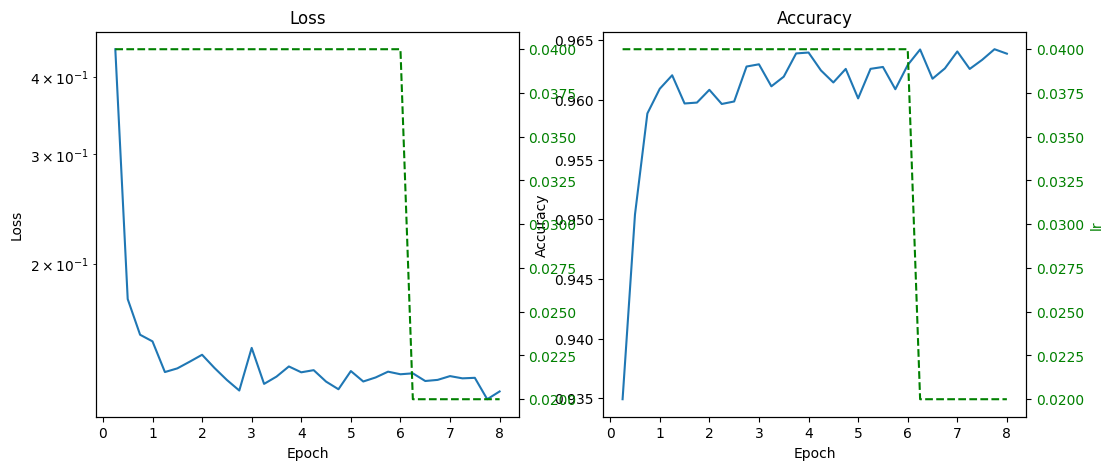

In [24]:
import matplotlib.pyplot as plt

# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
epochs = [h["epoch"] for h in hist]
#plot lr in second axis for each 
ax2b = ax2.twinx()
ax2b.plot(epochs, [h["lr"] for h in hist], 'g--')
ax2b.set_ylabel('learning rate', color='g')
ax2b.tick_params(axis='y', labelcolor='g')
ax1b = ax1.twinx()
ax1b.plot(epochs, [h["lr"] for h in hist], 'g--')
ax1b.tick_params(axis='y', labelcolor='g')
# Plot the loss and accuracy
ax1.plot(epochs, [h["loss"] for h in hist])
ax2.plot(epochs, [h["test accuracy"] for h in hist])
# Set the labels and titles
ax1.set_xlabel("Epoch")
ax2.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_yscale('log') #log scale 
ax2.set_ylabel("Accuracy")
ax2b.set_ylabel("lr")
ax1.set_title("Loss")
ax2.set_title("Accuracy")
plt.show()

In [20]:
task = "LabelExtractor" if not first_token_only else "FirstTokenExtractor"
fileName = f'context{task}_{model_name}_l{layer}_e{len(hist)//log_per_epoch}.pth'

print("Saving TaskVec to ", fileName)
torch.save(TaskVec, fileName)

Saving TaskVec to  contextLabelExtractor_phi-1_5_l10_e6.pth


## Testing the model

### Load TaskVec

In [56]:
layer = 10
with_context = False
dataset_name = "TACRED"
dataset_name = "CoNLL2003"

# load results
xp_path = pathlib.Path.home() / "experiments_JeanZay"
#get all experiments directories
xp_paths= os.listdir(xp_path / "jobs")
jobs_path = xp_path / "jobs" / xp_paths[0]
#get jobs
print("loading all results from ", jobs_path)
results = loadResults(jobs_path)

fileName = "./checkpoints/TaskVec_gpt2-small_l8_e50.pth"
fileName = "./LabelExtractor_gpt2-medium_l12_e9.pth"
fileName = "./checkpoints/TaskVec_mistral-7B_l17_e20.pth"
fileName = "./checkpoints/LabelExtractor_phi-2_l15_e20.pth"
fileName = "./checkpoints/contextLabelExtractor_phi-2_l15_e6.pth"
fileName = "./contextLabelExtractor_gpt2-medium_l15_e14.pth"
fileName = get_taskVec(results, model_name, layer=layer, dataset_name=dataset_name, with_context = with_context)


# Get TaskVec from the model
TaskVec = torch.load(fileName)
print("TaskVec loaded from ", fileName)

loading all results from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor


100%|██████████████████████████████████████████████████████████████████████████| 1506/1506 [00:02<00:00, 505.59it/s]

found 3 results for layer 10 of EleutherAI/pythia-410m without context on CoNLL2003
found ['TaskVec_pythia-410m_l10_e9.993406593406593.pth'] 
TaskVec loaded from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/b460722b57e3eb9f1151664eed467d50b4a2c22d7d692049adb90c8b1b171fb7/TaskVec_pythia-410m_l10_e9.993406593406593.pth


In [8]:
test_dataloader = DataLoader(test_dataset, batch_size=20, shuffle=True)
eval_model(model, TaskVec, test_dataloader, prepend_bos=True, with_context=True)

0.9656465849338175

### Compute metrics

In [25]:
# with_context = True
# layer=15
data = test_dataset
data = test_dataset.data[:1000]
# test_dataset.data = data
# test_dataset.augment_with_repr(model, layer, batch_size=100)

for d in data:                  # drop inferered key in data
    d.pop("inferred", None)
acc = compute_metrics(model, TaskVec,
                       data,
                       with_context=with_context, 
                       max_tokens=20, b_size=30)
print(f" Model {model_name}, layer {layer}:\n Evaluation metrics on test set:")
for k,v in acc.items():
    print(f"\t- {k}: {v:.3f}")
# print(f" Evaluation accuracy on train set: {acc:.3f}")

100%|██████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1002462.72it/s]

 Model phi-1_5, layer 10:
 Evaluation metrics on test set:
	- Partial Match: 0.727
	- Exact Match: 0.625
	- Chr-F: 66.166
	- Version: 1.200


In [22]:
compute_metrics(model, best_TaskVec,
                       test_dataset,
                       with_context=with_context, 
                       max_tokens=20, b_size=30, prepend_bos=True)

100%|██████████████████████████████████████████████████████████████████████| 5389/5389 [00:00<00:00, 1269694.66it/s]


{'Partial Match': 0.8318797550565967,
 'Exact Match': 0.7693449619595473,
 'Chr-F': 79.61170600872856,
 'Version': 1.2}

In [52]:
#print some fail examples
print("Original:".center(40) + " | " + "Inferred:".center(40)+ '\n'+"-"*84)
limit = 10
fails = set()
for item in data:
    if len(fails) >= limit: break
    item = data[np.random.randint(len(data))]
    if item['entity'] == item['inferred'] or item['inferred'] in fails: continue
    fails |= {item['inferred']}
    print(f"{item['entity'].center(40)} | {item['inferred'].center(40)}")

               Original:                 |                Inferred:                
------------------------------------------------------------------------------------
                Italian                  | Italian canto

Italian canto

Italian canto

Italian canto
                Cardiff                  | The city of London is a city in the United Kingdom. It is the capital of the
             Shahid Afridi               | The following is a list of the most popular and most used terms in the language of the
              Corrado Covi               | i

I am a newbie to the world of photography. I am a photographer and I
             Central Africa              | The African continent is a continent that is inhabited by a number of different ethnic groups. The
                 NYMEX                   | I am a newbie to the world of cryptocurrency. I am trying to understand the process
               MINNESOTA                 | The Minnesota State House of Representatives is a ho

In [11]:
#print some with context
print("Original:".center(40) + " | " + "Inferred:".center(40)+ '\n'+"-"*84)
limit = 10
fails = set()
for item in data:
    if len(fails) >= limit: break
    item = data[np.random.randint(len(data))]
    if item['entity'] == item['inferred'] or item['inferred'] in fails: continue
    fails |= {item['inferred']}
    print(f"\n{item['entity'].center(40)} | {item['inferred'].center(40)}")
    print(f"context: {item['text']}")

               Original:                 |                Inferred:                
------------------------------------------------------------------------------------

                 Aquash                  |                  Kamook                 
context: But Kamook implicated Peltier all over again in the deaths of 2 FBI agents at a famous shootout on Pine Ridge a few months before Aquash turned up dead.

               right now                 |          the Corporate Library          
context: `` I 'm sure there are probably people working on that right now, '' said Paul Hodgson, senior research associate for the Corporate Library, a corporate governance research firm.

               Last month                |              the first year             
context: Last month, the American Association of University Women reported that in the first year after graduating, women working full-time make 20 percent less on average than their male classmates.

            accepting bri

In [15]:
dataset = test_dataset
ind = np.random.randint(len(dataset))
prompt = dataset[ind]["text"]
print(prompt)
print("target:", dataset[ind]["entity"])
# s = dataset[ind]["representation"].view(1,-1)

# s = repr
# gen = utils.generate_from_repr(model, s, TaskVec, retr_prompt="_ >", max_tokens=10, do_sample=True)
# print("generation:","".join(gen[3:-1]))

Director Ray Griggs, born in 1974, is the writer of the film Super Capers, starring Michael Rooker and Tom Sizemore.
target: Michael Rooker


In [43]:

def generate_from_repr( model, 
                        repr, 
                        taskVector = None, 
                        retr_prompt:str ="_ named",
                        max_tokens = 10,
                        do_sample = False,
                        prepend_bos=True,
                        ):
        """
        Args:
                repr: The representation vectors
                Model: the GPT model to use
                taskVector: the task vector to use. If None, will use default prompt
                max_tokens: num of tokens to generate
                do_sample: if True, sample from logits, else take argmax
                prepend_bos: if True, prepend '<BOS>' token to the input

        """
        inp_toks = model.to_tokens(retr_prompt, prepend_bos=prepend_bos)
        rep_idx = 1 if prepend_bos else 0
        replace_hook_name = tl.utils.get_act_name('embed')
        taskVec_idx = rep_idx + 1
        
        if taskVector is not None:
            taskVector = taskVector.view(1,-1)
            b_taskVec = taskVector.repeat(repr.shape[0],1).cuda()
        
        repr = repr.cuda()
        # print(b_taskVec.shape)
        # print(repr.shape)
        
        for i in range(max_tokens):
                # print(inputs, targets)
                if taskVector is not None:
                    logits = model.run_with_hooks(
                            inp_toks,
                            return_type = "logits",
                            fwd_hooks=[
                            (replace_hook_name, utils.get_replace_with_rep_hook(repr, torch.tensor([rep_idx]))), # replace '_' by the subject Representation
                            (replace_hook_name, utils.get_replace_with_rep_hook(b_taskVec, torch.tensor([taskVec_idx]))) # replace 'called' by TaskVec Representation
                            ])
                else:
                    logits = model.run_with_hooks(
                            inp_toks,
                            return_type = "logits",
                            fwd_hooks=[
                            (replace_hook_name, utils.get_replace_with_rep_hook(repr, torch.tensor([rep_idx]))), # replace '_' by the subject Representation
                            ])

                final_logits =  logits[0,-1,:] #extract logits for last token 

                if do_sample:
                        new_tok = tl.utils.sample_logits(
                        final_logits,
                        top_k=None,
                        top_p=None,
                        temperature=0,
                        freq_penalty=0,
                        tokens=inp_toks,
                        ).view(1,-1)
                else:       #greedy generation
                        new_tok = final_logits.argmax(-1).view(1,-1) 
                
                inp_toks = torch.hstack((inp_toks,new_tok))
                # stop if EOS token
                if new_tok == model.tokenizer.eos_token_id: break
        print(inp_toks)
        return model.tokenizer.decode(inp_toks.view(-1)[1:])

In [60]:
limit = 1000
layer = 17
test_dataset.data = test_dataset.data[:limit]
print("length:",len(test_dataset))
test_dataset.augment_with_repr(model, layer, batch_size=20)

length: 1000


100%|███████████████████████████████████████████████████████████████████████████████| 50/50 [00:53<00:00,  1.08s/it]


In [ ]:
## Check how does the model reads the TaskVec
utils.generate_from_repr(model, repr, TaskVec, retr_prompt="_ >", do_sample=True)

## Conclusion
The model is able to generate text from a representation of a subject.
It can do it for known entities, but likely not for representations of an unknown label (unknow name), even if there are clues that it knows where to look.
- adding the representation makes Phi1.5 model jump from 75 to 85% LM accuracy.
- But only 25% for the first token, whereas it can reach 32% if it is trained solely on predicting the first token 


# Convergence of representations
During Representation Construction
Here, we explore how the representation that we extract from the model is constructed by the Transformer.

### Compute cache

In [181]:
in_voc_space = False

#get one example from the dataset
ind = np.random.randint(len(test_dataset))
# ind = 9296
# ind = 64
ind = 2574
print(f"sample {ind} from test dataset")
target = test_dataset[ind]["entity"]
prompt = test_dataset[ind]["text"].split(target)[0] + target
toks = model.to_str_tokens(prompt)

#tokenize the prompt
print( "prompt:", test_dataset[ind]["text"])
print( "|".join(toks))
print(f"{len(toks)} tokens, target:{target}")

layer = 20
hooks = [ # name, type, color
        # ["normalized","ln1", "green"],
        ["attn_out","", "blue"],
        # ["normalized","ln2", "lightgreen"],
        ["mlp_out","", "cyan"],
        ["resid_post","","red"]
        ]
# print hooks 
print("will use hooks:")          
for h,t,_ in hooks:
    hook = tl.utils.get_act_name(h, 0, t)
    print(hook)
similarities = torch.zeros(len(toks), len(hooks) * model.cfg.n_layers)
random_similarities = torch.zeros(len(hooks) * model.cfg.n_layers)
n = len(hooks)

#mean similarity between vectors in a batch of representations
@torch.no_grad()
def mean_similarities(reprs):
    sims = []
    for i in range(reprs.shape[0]-1):
        sim = torch.cosine_similarity(reprs[i], reprs[i+1:], dim=-1)
        sims.append(sim.mean().cpu().detach())
    return torch.tensor(sims).mean().cpu().detach()

#get whole hidden states
_ , cache = model.run_with_cache(prompt)
repr = cache[tl.utils.get_act_name("resid_post", layer, "")][:,-1,:] # 1 x n_tokens x dim
repr = repr.cuda().view(1,-1) 
if in_voc_space:
    repr = repr @ model.W_U #transform in vocab space
for l in range(model.cfg.n_layers):
    for i, (h,t,_) in enumerate(hooks):
        hook = tl.utils.get_act_name(h, l, t)
        reprs = cache[hook] # 1 x n_tokens x dim : representations of the tokens at given hook
        reprs = reprs.type(model.W_U.dtype) #cast to dtype of model
        if in_voc_space:
            reprs = reprs @ model.W_U
        #compute similarities with the target representation
        sim = torch.cosine_similarity(
            reprs,
            repr,   
            dim=-1)
        similarities[:,n*l+i] = sim.squeeze(0)
        random_similarities[n*l+i] = mean_similarities(reprs.view(-1,reprs.shape[-1]))

#add embeddings
hook = tl.utils.get_act_name("embed")
reprs = cache[hook].squeeze(0) # n_tokens x dim
sim = torch.cosine_similarity(reprs,
                              repr,     # already in vocab space
                              dim=-1).cpu().detach().view(-1,1)
similarities = torch.hstack((sim, similarities )).cpu().detach().numpy()

del cache
gc.collect()
torch.cuda.empty_cache()

sample 2574 from test dataset
prompt: Adding to the comments by " Mr Yen ", as Sakakibara is known for his prominence in the currency market, was BOJ governor Matsushita's remark.
<|endoftext|>|Adding| to| the| comments| by| "| Mr| Yen| ",| as| Sak|ak|ib|ara
15 tokens, target:Sakakibara
will use hooks:
blocks.0.hook_attn_out
blocks.0.hook_mlp_out
blocks.0.hook_resid_post


## Plotting Convergence to extracted representation

#### Plot Everything

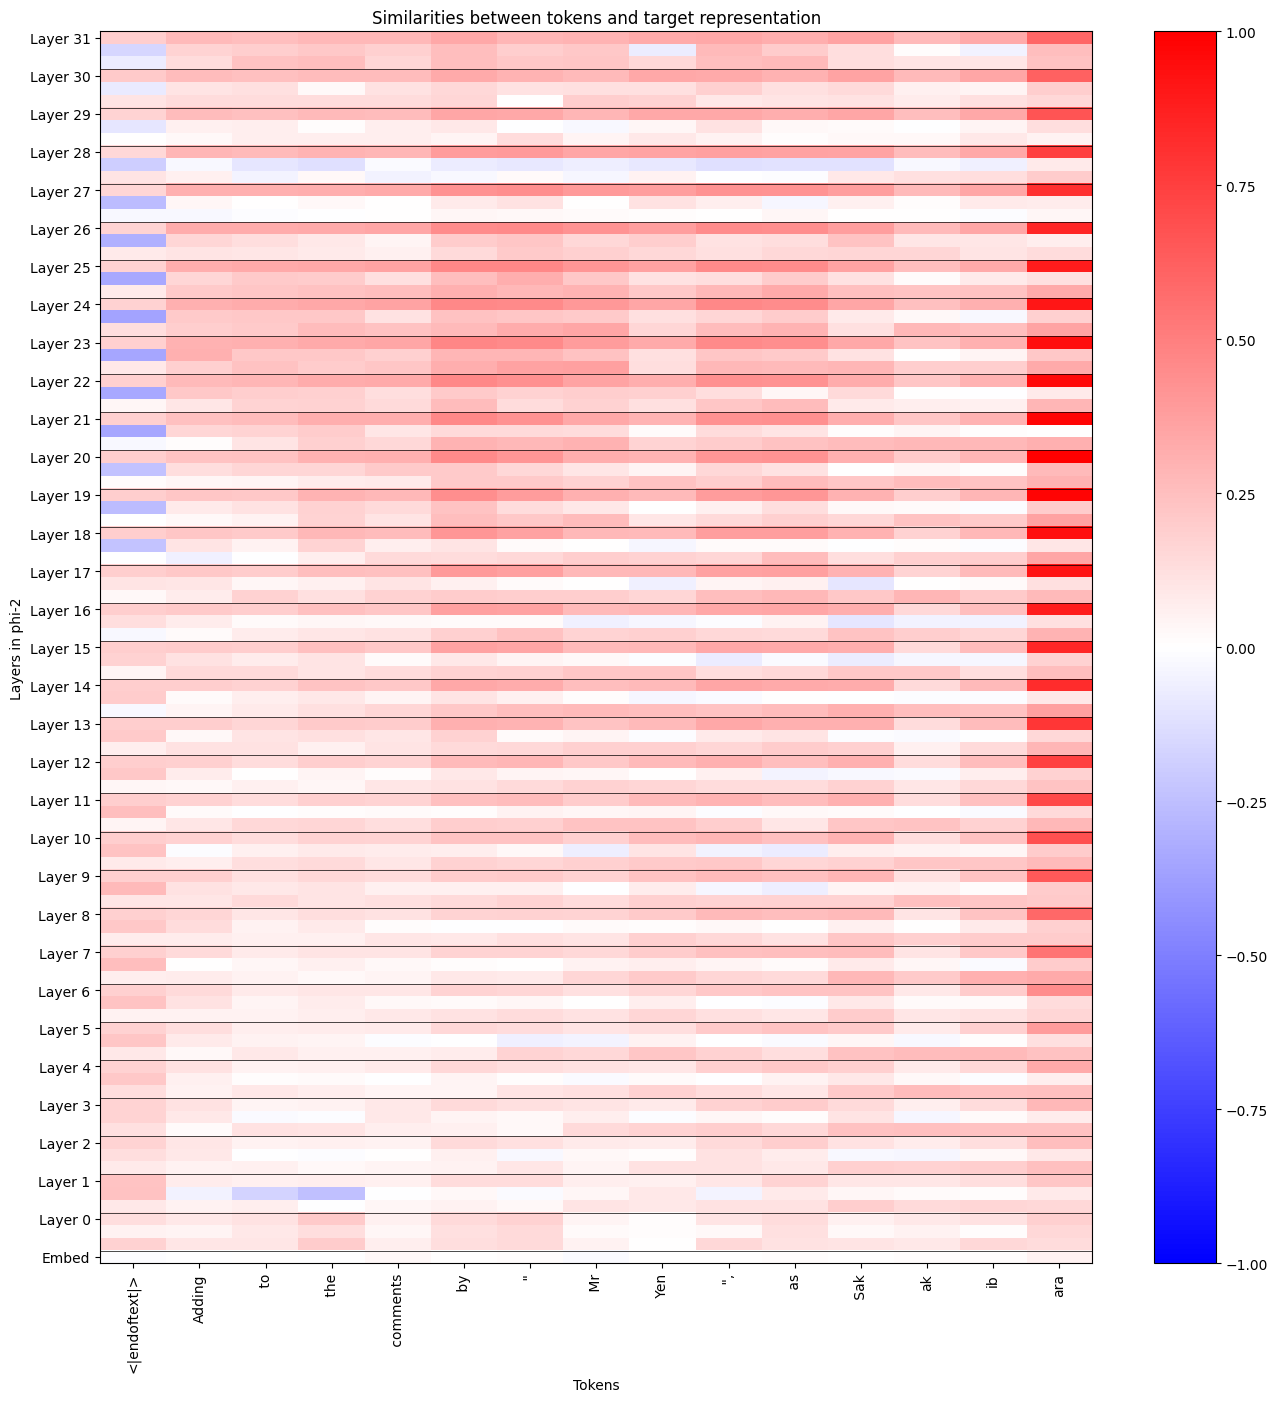

In [182]:
import matplotlib.pyplot as plt

#show image of similarities
plt.figure(figsize=(16,16))
plt.imshow(similarities.T, aspect='auto', cmap='bwr')
plt.colorbar()
#colorbar with scale from 0 to 1
#draw lines separating layers
for i in range(model.cfg.n_layers + 1):
    plt.axhline(y=n*i+.5, color='black', linewidth=0.5)
plt.clim(-1,1)
plt.title("Similarities between tokens and target representation")
plt.ylabel(f"Layers in {model_name}")
plt.gca().invert_yaxis() #invert y axis
plt.yticks(np.array(range(0,1 + n*model.cfg.n_layers,n)), ["Embed"] + [f"Layer {i}" for i in range(model.cfg.n_layers)])
plt.xlabel("Tokens")
plt.xticks(range(len(toks)), toks, rotation=90)
plt.show()

#### Plot output of all layers

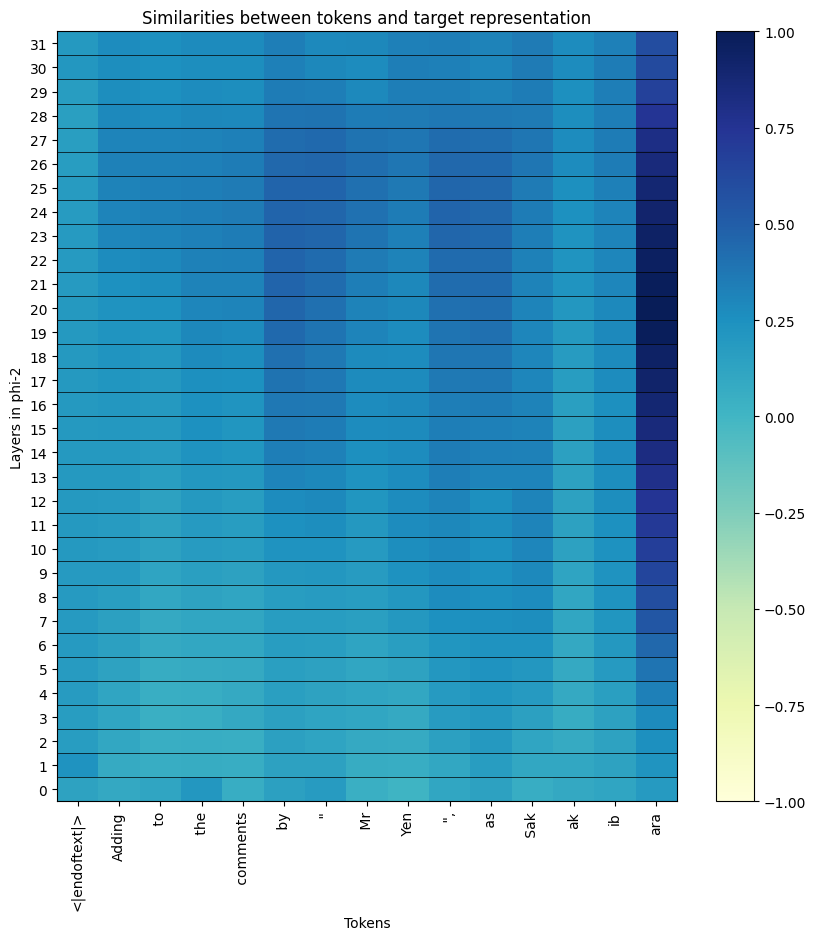

In [183]:
outputs_only = np.zeros((len(toks), model.cfg.n_layers))
for i in range(model.cfg.n_layers):
    outputs_only[:,i] = similarities[:,n*(i+1)] # 1 + n*(i+1) - 1
#show image of similarities
plt.figure(figsize=(10,10))
plt.imshow(outputs_only.T, aspect='auto', cmap=plt.cm.YlGnBu) #'bwr')
plt.colorbar()
#colorbar with scale from 0 to 1
#draw lines separating layers
for i in range(model.cfg.n_layers):
    plt.axhline(y=i+.5, color='black', linewidth=0.5)
plt.clim(-1,1)
plt.title("Similarities between tokens and target representation")
plt.ylabel(f"Layers in {model_name}")
plt.gca().invert_yaxis() #invert y axis
plt.yticks(np.array(range(0,model.cfg.n_layers)), [f"{i}" for i in range(model.cfg.n_layers)])
plt.xlabel("Tokens")
plt.xticks(range(len(toks)), toks, rotation=90)
plt.show()

#### Plot for Last token

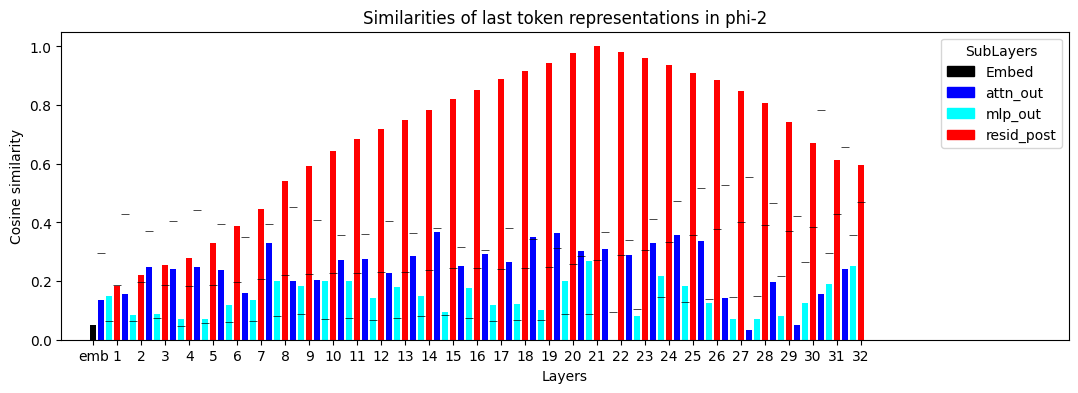

In [196]:
# Plot the last token similarities
plt.figure(figsize=(13, 4))

unique_colors = ["black"] + [c for _, _, c in hooks]
legend_labels = ["Embed"] + [h for h, _, _ in hooks]  # Labels corresponding to the unique colors
colors = ["black"] + [c for _, _, c in hooks] * model.cfg.n_layers
x = np.array(range(1, len(random_similarities)+1))
# plt.grid(axis='y')
plt.bar(range(similarities.shape[1]), similarities[-1, :], color=colors)
plt.hlines(random_similarities, x-.5, x+.5, color='black', linewidth=0.5, label="Random")
# plt.step([0.5] + list(x+.5), [0] + list(random_similarities.numpy()), color='black', linewidth=0.5, label="Random")
plt.title(f"Similarities of last token representations in {model_name}")
plt.ylabel("Cosine similarity")
plt.xlabel("Layers")
plt.xticks(range(0, n * model.cfg.n_layers + 1, n), ["emb"] + [f"{i+1}" for i in range(model.cfg.n_layers)])
plt.xlim(-4, similarities.shape[1] + 25)
# Create a custom legend with one entry per unique color
# Create a list of unique colors and labels

# Plot the legend manually by creating proxy artists (handles) for each color
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in unique_colors]
# plt.legend()
plt.legend(handles, legend_labels, 
           title="SubLayers",
            # loc="lower left",
            )
# Display the plot
plt.savefig("similarities.pdf")
plt.show()

#### Plot for given Layer

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


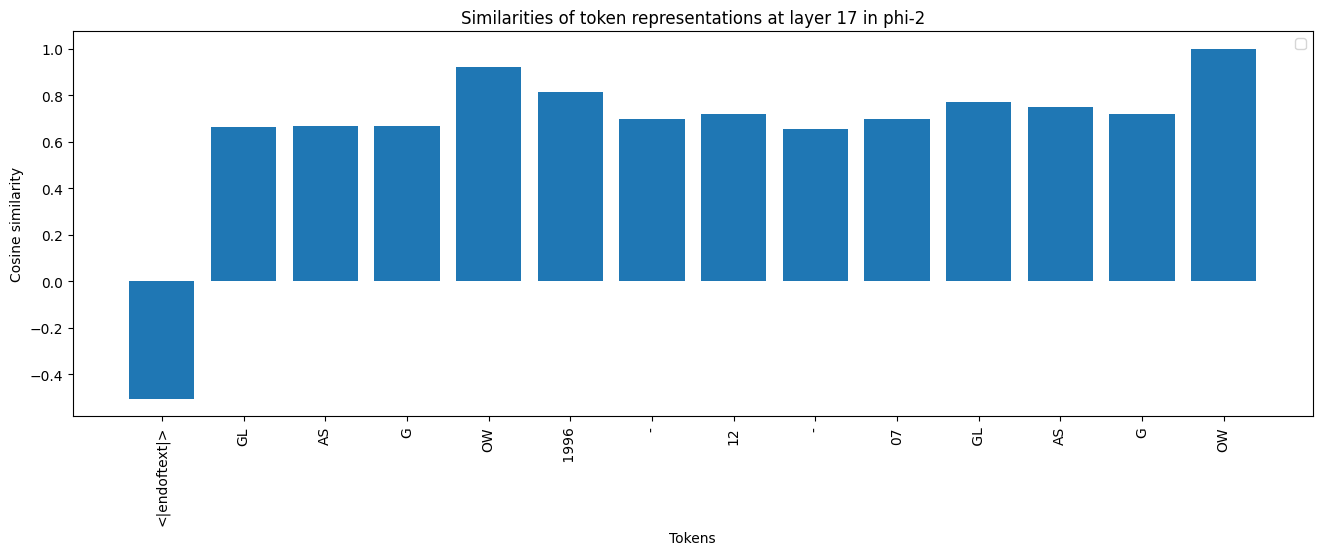

In [24]:
#plot the last token similarities
plt.figure(figsize=(16,5))

outputs = [similarities[i,n*(layer+1)] for i in range(len(toks))]
plt.bar(range(len(outputs)), outputs)

plt.title(f"Similarities of token representations at layer {layer} in {model_name}")
plt.ylabel("Cosine similarity")
plt.xlabel("Tokens")
plt.xticks(range(len(toks)), toks, rotation=90)
plt.legend()
plt.show()

# SubLayer Knockout

In [9]:
#get one example from the dataset
ind = np.random.randint(len(test_dataset))
# ind = 9296
print(f"sample {ind} from test dataset")
target = test_dataset[ind]["entity"]
prompt = test_dataset[ind]["text"].split(target)[0]+ target # 'in_context' method
toks = model.to_str_tokens(prompt)

#tokenize the prompt
print( "prompt:", test_dataset[ind]["text"])
print( "|".join(toks))
print(f"{len(toks)} tokens, target:{target}")

sample 340 from test dataset
prompt: Sevilla (Spain) 9 4 5 13
<|endoftext|>|S|ev|illa| (|Spain
6 tokens, target:Spain


In [200]:
layer = 17 # layer where to extract representations
to_voc_space = True
to_voc_space = False

hooks = [ # name, type, color
        ["attn_out","", "blue"], 
        ["mlp_out","", "cyan"],
        ]

#tokenize the prompt
tokens = model.to_tokens(prompt)
rep_ind = tokens.shape[-1] - 1
#get representations
repr = utils.get_representation(model, tokens=tokens, token_inds=[rep_ind], layer=layer, verbose=True)
# cast to model dtype
print(repr.shape, repr.dtype)
#transform in vocab space
if to_voc_space: repr = repr.cuda().view(1,-1) @ model.W_U


extract representation of tokens [14] at hook blocks.17.hook_resid_post
torch.Size([1, 2560]) torch.float32


In [201]:
# Compute similarities with the target representation and its knocked versions
print("will knock out hooks:")          
for h,t,_ in hooks:
    hook = tl.utils.get_act_name(h, 0, t)
    print(hook)

def get_knock_hook(ind):
    def Knockout_hook(tensor, ind, hook):
        tensor[:,ind,:] = 0 # batch, seq len, dim
        return tensor
    return lambda tensor , hook: Knockout_hook(tensor, ind, hook)

similarities = torch.zeros(tokens.shape[-1], len(hooks) * (layer + 2))
n = len(hooks)
for l in tqdm(range(layer+2)):
    for i, (h,t,_) in enumerate(hooks):
        for ind in range(tokens.shape[-1]):
            hook = tl.utils.get_act_name(h, l, t)
            knocked_repr = utils.get_representation(
                    model, 
                    tokens=tokens, 
                    token_inds=[rep_ind], 
                    layer=layer,
                    hooks = [(hook, get_knock_hook(ind))],
                    # verbose=True,
                    )
            knocked_repr = knocked_repr.type(model.W_U.dtype) #cast to dtype of model
            if to_voc_space: knocked_repr = knocked_repr.cuda().view(1,-1) @ model.W_U
            #compute similarities with the target representation
            sim = torch.cosine_similarity(
                # knocked_repr @ model.W_U,    # transform in vocab space
                knocked_repr,
                repr, 
                dim=-1)
            similarities[ind,n*l+i] = sim.squeeze(0).cpu().detach()

gc.collect()
torch.cuda.empty_cache()

will knock out hooks:
blocks.0.hook_attn_out
blocks.0.hook_mlp_out


100%|███████████████████████████████████████████████████████████████████████████████| 19/19 [00:45<00:00,  2.42s/it]


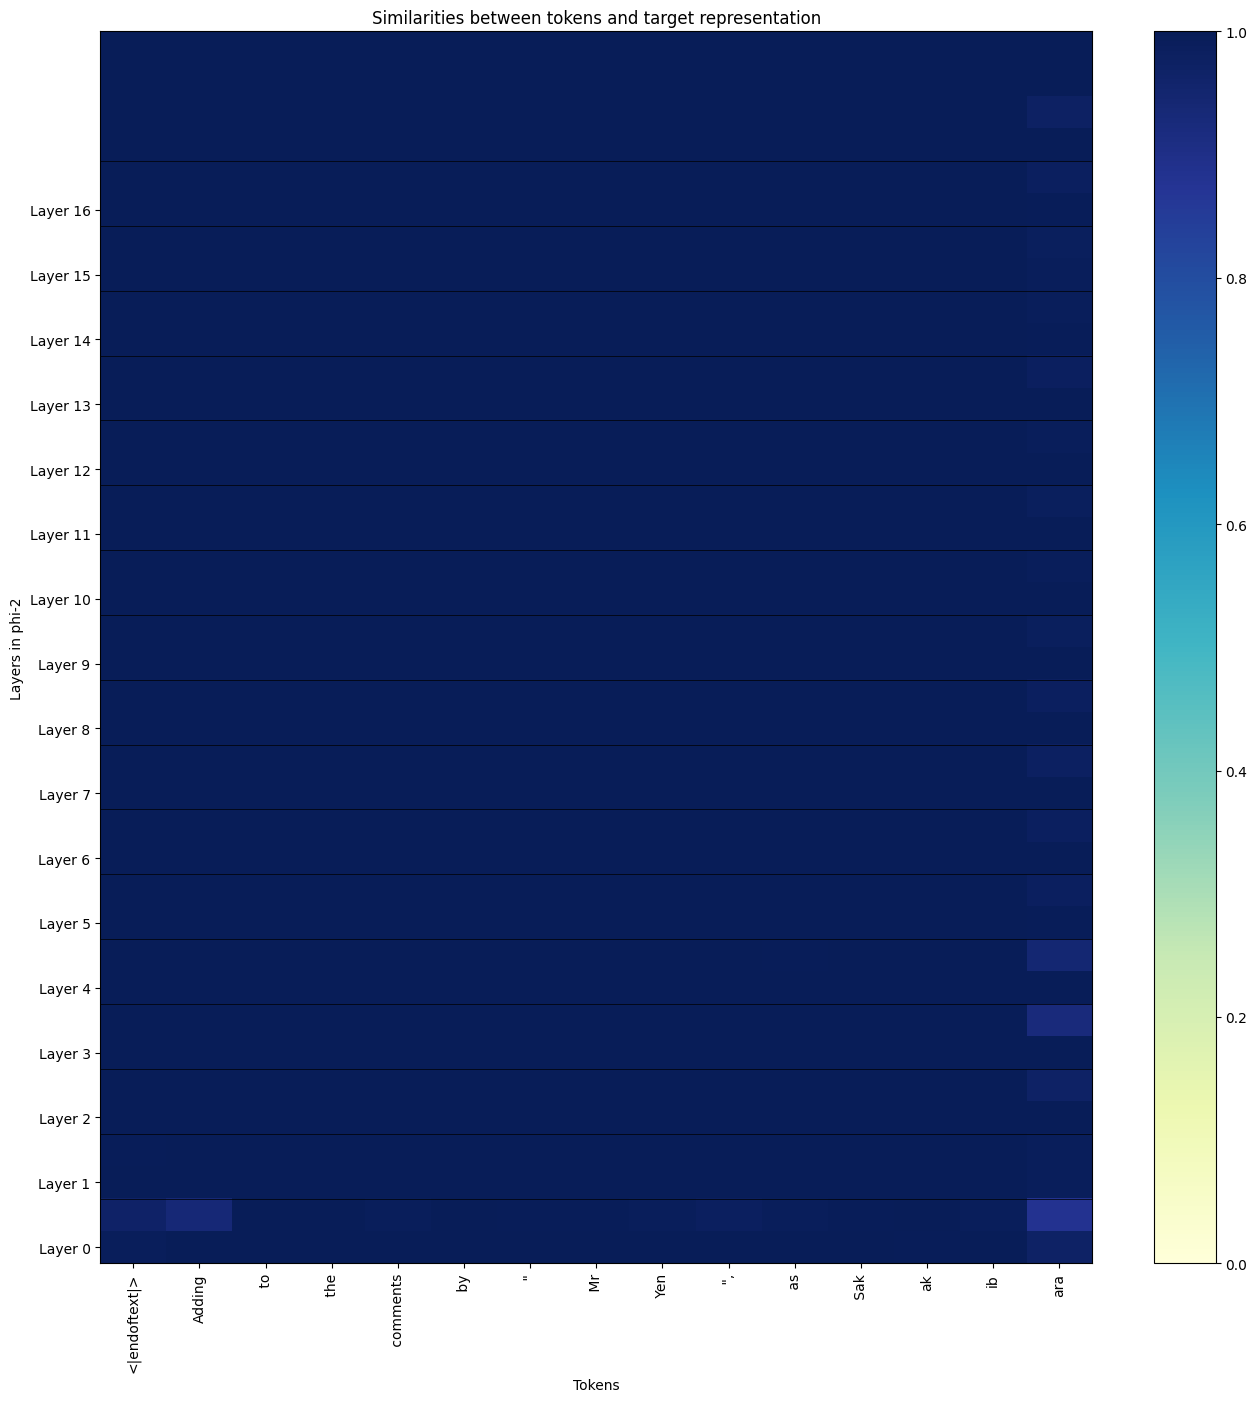

In [204]:
#show image of similarities
plt.figure(figsize=(16,16))
#reverse colorbar
plt.imshow(similarities.T, aspect='auto', cmap=plt.cm.YlGnBu) #'bwr')
plt.colorbar()
#colorbar with scale from 0 to 1
#draw lines separating layers
for i in range(layer + 1):
    plt.axhline(y=n*i-.5, color='black', linewidth=0.5)
plt.clim(0,1)
plt.title("Similarities between tokens and target representation")
plt.ylabel(f"Layers in {model_name}")
plt.gca().invert_yaxis() #invert y axis
plt.yticks(np.array(range(0,n*layer,n)), [f"Layer {i}" for i in range(layer)])
plt.xlabel("Tokens")
plt.xticks(range(len(toks)), toks, rotation=90)
plt.show()

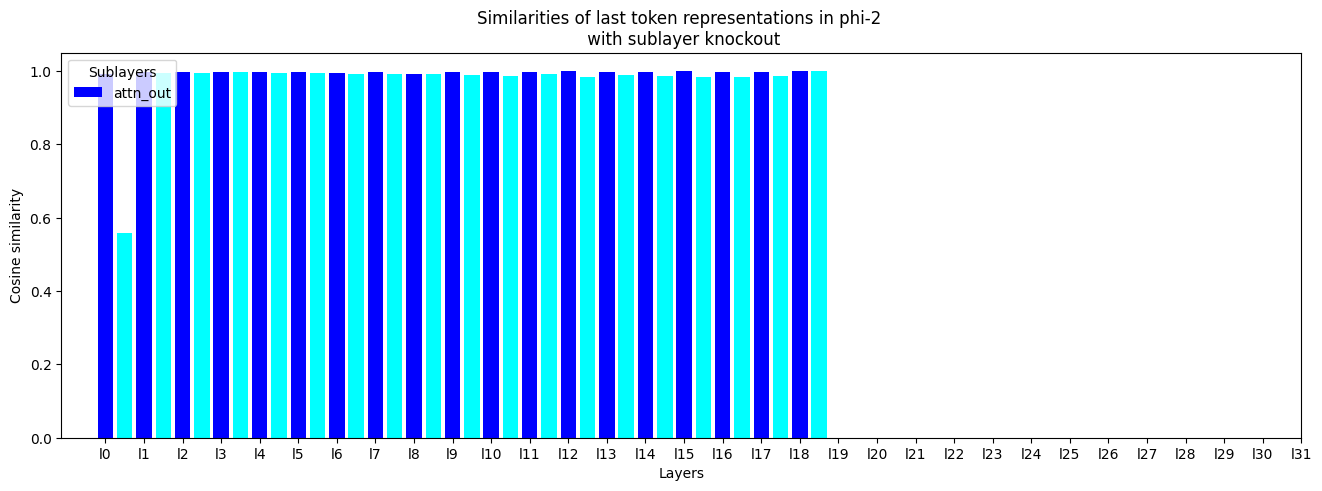

In [13]:
#plot the last token similarities
plt.figure(figsize=(16,5))

#color all multiples of n in red 
colors = [c for _,_,c in hooks]*(model.cfg.n_layers)
labels = [h for h,_,_ in hooks]*(model.cfg.n_layers)

plt.bar(range(similarities.shape[-1]),similarities[-1,:],
        #  label=labels, 
         color=colors)

plt.title(f"Similarities of last token representations in {model_name} \n with sublayer knockout")
plt.ylabel("Cosine similarity")
plt.xlabel("Layers")
plt.xticks(range(0, n*model.cfg.n_layers, n), [f"l{i}" for i in range(model.cfg.n_layers)])
plt.legend(labels, title="Sublayers", loc='upper left')
plt.show()

In [68]:
# quick sanity check 
_ , cache = model.run_with_cache(toks)      #get whole hidden states
repr2 = cache[tl.utils.get_act_name("resid_post", layer, "")][:,-1,:] # 1 x n_tokens x dim
repr2.cpu().allclose(repr)


True

# Attention Dissection

In [15]:
import circuitsvis as cv
import plotly.io as pio
# Plotly needs a different renderer for VSCode/Notebooks vs Colab argh
pio.renderers.default = "notebook_connected"
print(f"Using renderer: {pio.renderers.default}")
# Testing that the library works
cv.examples.hello("Victor")


Using renderer: notebook_connected


In [20]:
#get one example from the dataset
ind = np.random.randint(len(test_dataset))
# ind = 7989 # 'New Hampshire' - can be regenerated without context at layer 15
# ind = 4237 # 'English-language' - can almost be regenerated without context at layer 15
target = test_dataset[ind]["entity"]
context = test_dataset[ind]["text"]
print(f"sample {ind} from test dataset. Target: {target}")
prompt = context + ' ' + target # prompt used to build the representations
str_tokens = model.to_str_tokens(prompt)

#get whole cache for given prompt as it is done in 'augment_with_repr'
_ , cache = model.run_with_cache(prompt)

#display the prompt
html = cv.tokens.colored_tokens(str_tokens,[])
html.cdn_src = html.cdn_src.replace("margin: 15px", "margin: 50px")
html
#add padding at the end of html

sample 1493 from test dataset. Target: SIALKOT


## Attention while constructing the representation
Here, we just explore the use of `cv.attention.attention_patterns` function from `circuitsvis` that allows us to inspect the attention scores for each head of our model when run on the prompt that was used to retreive the representations

In [8]:
layer = 10
print(type(cache))
attention_pattern = cache["pattern", layer, "attn"].squeeze(0)
print("pattern shape:", attention_pattern.shape)
print(f"Layer {layer} Head Attention Patterns:")
cv.attention.attention_patterns(tokens=str_tokens, attention=attention_pattern)

<class 'transformer_lens.ActivationCache.ActivationCache'>
pattern shape: torch.Size([32, 27, 27])
Layer 10 Head Attention Patterns:


## Attention while generating labels
Now, we explore what is happening on the attention side when we perform the label generation. 

### Retrieve corresponding Trained TaskVector

In [12]:
layer = 15
with_context = True
dataset_name = "TACRED"
# load results
xp_path = pathlib.Path.home() / "experiments_JeanZay"
#get all experiments directories
xp_paths= os.listdir(xp_path / "jobs")
jobs_path = xp_path / "jobs" / xp_paths[0]
#get jobs
print("loading all results from ", jobs_path)
results = loadResults(jobs_path)
# Get TaskVec from the model
fileName = get_taskVec(results, model_name, layer=layer, dataset_name=dataset_name, with_context = with_context)
TaskVec = torch.load(fileName)
print("TaskVec loaded from ", fileName)

loading all results from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor


100%|█████████████████████████████████████████████████████████████████████████████| 550/550 [00:10<00:00, 50.53it/s]

found 1 results for layer 15 of phi-2 with context on TACRED
found ['TaskVec_phi-2_l15_e20.pth'] 
TaskVec loaded from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/d375efe862be619fc1a3688f935d768bbcbd16aa7ae9bf928adbadbb99e74819/TaskVec_phi-2_l15_e20.pth


### Generate with TaskVec

In [24]:
#get all representations at given layer from cache
with_context = False
with_context = True
layer = 15

repr = cache[tl.utils.get_act_name("resid_post", layer, "")][0,-1,:] # n_tokens x dim
repr = repr.detach().cuda()
data = [{"id": 0, "text": context, "representation": repr, }]
infer_entities(model, TaskVec, data, with_context=with_context,
                return_attn_pattern=True,
                )
print("inferred '",data[0]["inferred"],"' from representation extracted at layer", layer, "of model", model_name) 


100%|█████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.24it/s]

inferred ' SIALKOT ' from representation extracted at layer 15 of model phi-2


In [25]:
attn_layer = 10
#get the attention pattern for the inferred entity at the given layer
pattern = data[0]["attn_pattern"][attn_layer]
str_tokens = model.to_str_tokens((context + ' _ > ' if with_context else '_ > ') + data[0]["inferred"])
print(f"Layer {attn_layer} Head Attention Patterns:")
cv.attention.attention_patterns(tokens=str_tokens, attention=pattern)

Layer 10 Head Attention Patterns:


In [ ]:
#use 'attention_pattern' to display only for one head
cv.attention.attention_heads(tokens=str_tokens, attention=pattern)

# Train Linear Layer to filter representations

### Load TaskVec

In [3]:
# load results
xp_path = pathlib.Path.home() / "experiments_JeanZay"
#get all experiments directories
xp_paths= os.listdir(xp_path / "jobs")
jobs_path = xp_path / "jobs" / xp_paths[0]
#get jobs
print("loading all results from ", jobs_path)
results = loadResults(jobs_path)

loading all results from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor


100%|███████████████████████████████████████████████████████████████████████████| 1362/1362 [02:05<00:00, 10.82it/s]


In [58]:
with_context = True
with_context = False

train_TaskVec = False
train_TaskVec = True

# Get TaskVec from the model
fileName = get_taskVec(results, model_name, layer=layer, dataset_name=dataset_name, with_context = with_context)
dtype = model.W_U.dtype
TaskVec = torch.load(fileName).type(dtype).detach().cuda()
print("TaskVec loaded from ", fileName)

if train_TaskVec:
    TaskVec.requires_grad_(True)

found 1 results for layer 15 of phi-3 without context on CoNLL2003
found ['TaskVec_phi-3_l15_e9.993406593406593.pth'] 
TaskVec loaded from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/5ab4482f75f1549d8b99b21e47bb062811062ccef0e248df2e43c119b206fc86/TaskVec_phi-3_l15_e9.993406593406593.pth


### Test it

In [8]:
# with_context = False #test generalization without context
# with_context = True
print(f"Computing metrics on {dataset_name} dataset with {model_name} model at layer {layer} {'with' if with_context else 'without'} context...")
compute_metrics(model, TaskVec, test_dataset, with_context=with_context, max_tokens=100, b_size=5, prepend_bos=True)

Computing metrics on CoNLL2003 dataset with phi-1_5 model at layer 15 without context...


100%|███████████████████████████████████████████████████████████████████████| 5389/5389 [00:00<00:00, 615184.37it/s]


{'Partial Match': 0.5655965856374096,
 'Exact Match': 0.5064019298571163,
 'Chr-F': 47.73251208162669,
 'Version': 1.2}

In [97]:
#pop inferred key in data
for d in test_dataset:
    d.pop("inferred", None)

## Train Projection

In [60]:
dim = model.QK.shape[-1]
linear_model = torch.nn.Linear(dim, dim, bias=True)
#initialize the linear model with identity
linear_model.weight.data = torch.eye(dim).type(dtype)
linear_model.bias.data = torch.zeros(dim, dtype=dtype)
linear_model = linear_model.cuda()

hist = []
#freeze the model and the task vector
for param in model.parameters():
    param.requires_grad = False

In [50]:
#Training params
lr = 1e-3
batch_size = 30
epochs = 5
logs_per_epoch = 4
clip = 1.0 #gradient clipping
prepend_bos = True
first_token_only = False

if hist: 
    last_epoch = hist[-1]["epoch"]
else :
    last_epoch = 0
dtype = model.W_U.dtype
eos_tok_str = model.tokenizer.eos_token
replace_hook_name = tl.utils.get_act_name('embed') #pos_embed for gpt2 ... 

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
n_log = len(train_dataloader) // logs_per_epoch
val_dataloader = DataLoader(val_dataset, batch_size=10, shuffle=True)

# optim = torch.optim.Adam([TaskVec] + list(linear_model.parameters()) , lr=lr)
optim = torch.optim.Adam(linear_model.parameters() , lr=lr)

#Cosine annealing scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, len_loader//2, eta_min=lr/10)

gc.collect()
torch.cuda.empty_cache()
print(f"{'Resuming' if hist else 'Starting'} training TaskVec on {dataset_name} for layer {layer} of {model_name} with{'out' if not with_context else ''} context...")
b_count = -1
for epoch in range(epochs):
    epoch += last_epoch
    m_loss = 0
    for batch in tqdm(train_dataloader):
                
        b_count += 1
        entities = batch["entity"]
        texts = batch["text"]
        reps = batch["representation"].squeeze(1).cuda()
        b_size = reps.shape[0]
        b_taskVec = TaskVec.repeat(b_size,1).cuda()
        
        if first_token_only:
            entities = [toks[0] for toks in model.to_str_tokens(entities,prepend_bos=False)]
        else:    
            entities = [ent + eos_tok_str for ent in entities] # take whole label add eos token

        if with_context:
                    prompts = [txt + "_ >" for txt in texts]
                    context_toks = model.to_tokens(prompts, prepend_bos=prepend_bos, padding_side="left") 
                    entities_toks = model.to_tokens(entities, prepend_bos=False, padding_side="right")
                    inputs = torch.cat([context_toks, entities_toks], dim=1)
                    rep_idx = context_toks.shape[1] - 2
        else:
            rep_idx = 1 if prepend_bos else 0 
            prompts = ["_ > " + ent for ent in entities]
            inputs = model.to_tokens(prompts, prepend_bos=prepend_bos,)

        rep_idxs = torch.tensor(b_size * [rep_idx])
        taskVec_idxs = torch.tensor(b_size * [rep_idx + 1])
        targets = inputs[:,rep_idx+1:] #don't take the '<eos>', <context>, '_' tokens into account

        #transform the representations with linear model
        reps = linear_model(reps)

        logits = model.run_with_hooks(
                inputs,
                return_type = "logits",
                fwd_hooks=[
                    (replace_hook_name, utils.get_replace_with_rep_hook(reps, rep_idxs)), # replace '_' by the subject Representation
                    (replace_hook_name, utils.get_replace_with_rep_hook(b_taskVec, taskVec_idxs)) # replace 'called' by TaskVec Representation
                    ]
            ,)

        # LM Loss and optimization 
        loss = model.loss_fn(logits[:, rep_idx+1:,:], targets) # take only the loss on the entity tokens
        loss.backward()
        optim.step()
        optim.zero_grad()
        m_loss += loss.item()
        
        # scheduler.step()
        
        if b_count % n_log == 0:
            m_loss = m_loss / n_log
            e = epoch + b_count/len_loader
            acc = eval_model(
                            model,
                            TaskVec,
                            val_loader=val_dataloader, 
                            first_token_only=first_token_only, 
                            with_context=with_context,
                            prepend_bos=prepend_bos,
                            transform=linear_model,
                            # metric='loss'
                            )
            lr = scheduler.get_last_lr()[0]
            print(f"Epoch {e:.1f},  Batch {b_count}/{len_loader}, Loss: {m_loss:.3f}, Test Acc: {acc:3f}, lr:{lr:.4f}")
            
            #save best taskVec according to test accuracy
            # if hist and acc >= max([h["test accuracy"] for h in hist]):
            #     print(f" {acc:.3f} is the best accuracy so far, saving TaskVec ...")
            #     best_TaskVec[:] = TaskVec[:]
            hist.append({"epoch":e, "loss": m_loss, "test accuracy": acc, "lr":lr})
            m_loss = 0
    b_count = 0        

task = "LabelExtractor" if first_token_only else "FirstTokenExtractor"
fileName = f'{task}_{model_name}_l{layer}_e{hist[-1]["epoch"]}.pth'


Resuming training TaskVec on CoNLL2003 for layer 15 of phi-1_5 without context...


  0%|                                                                            | 1/759 [00:54<11:34:25, 54.97s/it]

Epoch 10.0,  Batch 0/759, Loss: 0.000, Test Acc: 0.894428, lr:0.0010


 25%|██████████████████▊                                                        | 190/759 [03:25<2:40:21, 16.91s/it]

Epoch 10.2,  Batch 189/759, Loss: 0.006, Test Acc: 0.894822, lr:0.0010


...

 75%|█████████████████████████████████████████████████████████▌                   | 567/759 [07:05<53:53, 16.84s/it]

Epoch 14.7,  Batch 567/759, Loss: 0.004, Test Acc: 0.896005, lr:0.0010


100%|████████████████████████████████████████████████████████████████████████████▋| 756/759 [09:25<00:50, 16.82s/it]

Epoch 15.0,  Batch 756/759, Loss: 0.004, Test Acc: 0.894827, lr:0.0010


100%|█████████████████████████████████████████████████████████████████████████████| 759/759 [09:26<00:00,  1.34it/s]


In [51]:
#save linear model
torch.save(linear_model, f"./checkpoints/LinearModel_CoTrained_{model_name}_l{layer}_{'' if with_context else 'no'}Context.pth")

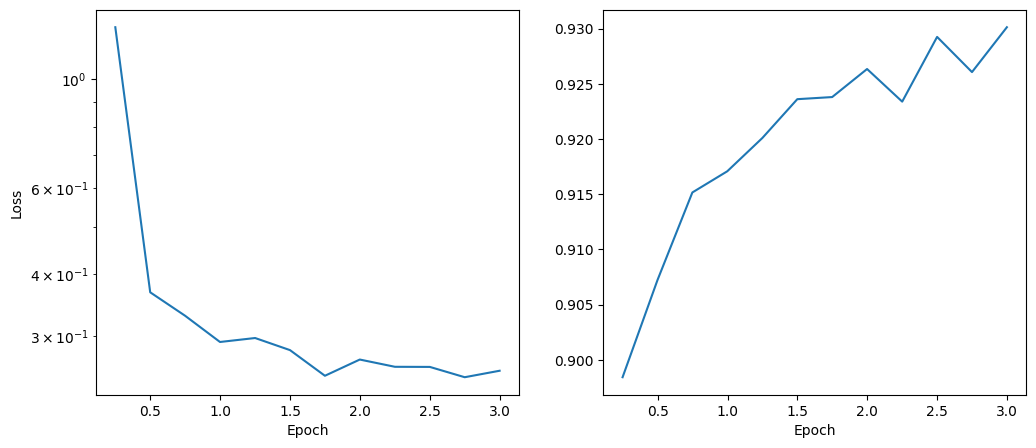

In [15]:
# plot the training history
import matplotlib.pyplot as plt

# Create a figure and two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

epochs = [h["epoch"] for h in hist]
losses = [h["loss"] for h in hist]
test_acc = [h["test accuracy"] for h in hist]
# Plot the loss and accuracy
ax1.plot(epochs, losses)
ax2.plot(epochs, test_acc)
#log 
ax1.set_yscale('log')
# Set the labels and titles
ax1.set_xlabel("Epoch")
ax2.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
plt.show()


## Analysis

Weights of the linear model: (2048, 2048), max:2.02, min:-1.09
Biases of the linear model: torch.Size([2048]), max:0.38, min:-0.48
Eigenvalues of the weight matrix: max:23.77+4.20j, min:-8.49-2.48j


Text(0.5, 1.0, 'Linear model weights')

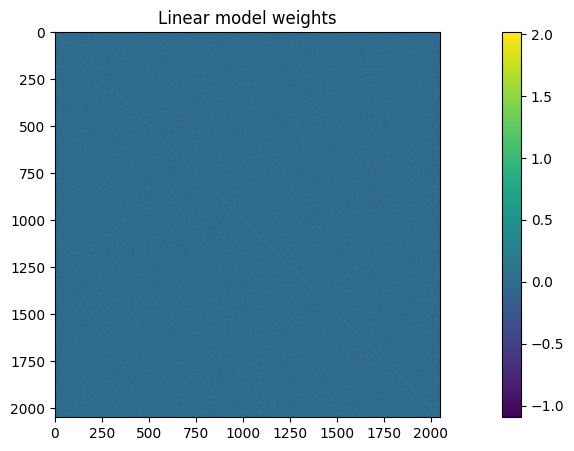

In [29]:
### Plot learned weights of the linear model
W = linear_model.weight.float().cpu().detach().numpy()
print(f"Weights of the linear model: {W.shape}, max:{W.max():.2f}, min:{W.min():.2f}")
print(f"Biases of the linear model: {linear_model.bias.shape}, max:{linear_model.bias.max():.2f}, min:{linear_model.bias.min():.2f}")
#eigenvalues of the weight matrix
eigvals = np.linalg.eigvals(W)
print(f"Eigenvalues of the weight matrix: max:{eigvals.max():.2f}, min:{eigvals.min():.2f}")
#plot the weights of the linear model
plt.figure(figsize=(16,5))
plt.imshow(W)
plt.colorbar()
plt.title("Linear model weights")


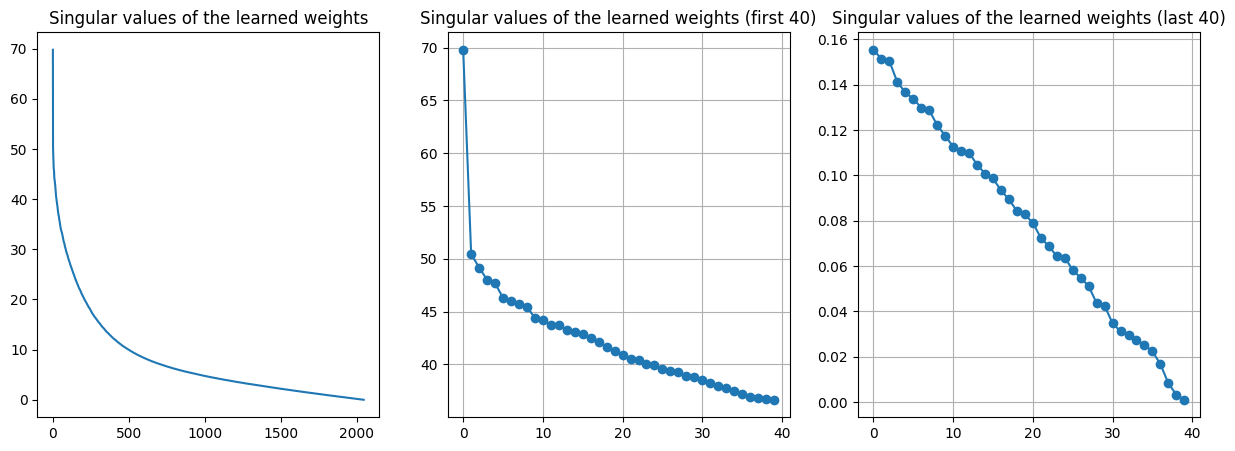

In [56]:
#svd for the learned weights
with torch.no_grad():
    U, S, Vh = torch.linalg.svd(
        linear_model.weight.float(),
        full_matrices=True)
N = 40
# plot of the singular values and a zoom on the first N
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(S.detach().cpu().numpy())
ax[0].set_title("Singular values of the learned weights")
ax[1].plot(S.detach().cpu().numpy()[:N], 'o-')
ax[1].set_title(f"Singular values of the learned weights (first {N})")
ax[1].grid()
ax[2].plot(S.detach().cpu().numpy()[-N:], 'o-')
ax[2].set_title(f"Singular values of the learned weights (last {N})")
ax[2].grid()
plt.show()

In [53]:
import copy
# test_dataset = augmented_data
#build new dataset with cleaned representations:

cleaned_test_dataset = copy.deepcopy(test_dataset)

#get repr
cleaned_test_dataset.augment_with_repr(model, layer, batch_size=10)

#clean representations
for item in tqdm(cleaned_test_dataset):
    item["representation"] = linear_model(item["representation"].cuda()).cpu().detach()

100%|████████████████████████████████████████████████████████████████████████| 5389/5389 [00:00<00:00, 11759.12it/s]


In [54]:
i = np.random.randint(len(cleaned_test_dataset))
#check difference between raw and cleaned representations
print(cleaned_test_dataset[i]["representation"])
print(test_dataset[i]["representation"])
print(f"norm of raw representation: {torch.norm(test_dataset[i]['representation']):.3f}")
print(f"norm of cleaned representation: {torch.norm(cleaned_test_dataset[i]['representation']):.3f}")
print(f"similarity: {torch.cosine_similarity(cleaned_test_dataset[i]['representation'], test_dataset[i]['representation'], dim=-1):.3f}")

tensor([ -2.0625, -39.0000,  42.0000,  ...,  12.3125,  12.4375,  65.5000],
       dtype=torch.bfloat16)
tensor([ 2.3438, -2.6250,  3.4688,  ...,  0.5156, -2.2188,  0.1240],
       dtype=torch.bfloat16)
norm of raw representation: 106.500
norm of cleaned representation: 2768.000
similarity: 0.162


In [55]:
print(f"Computing score with cleaned? representations: {model_name} model at layer {layer} {'with' if with_context else 'without'} context...")
print(compute_metrics(model=model, 
                      TaskVec=TaskVec, 
                      test_dataset=cleaned_test_dataset,
                      with_context=with_context,
                      b_size=5,
                      force_recompute=True,
                      ))

Computing score with cleaned? representations: phi-1_5 model at layer 15 without context...


100%|███████████████████████████████████████████████████████████████████████| 5389/5389 [00:00<00:00, 697971.35it/s]


{'Partial Match': 0.5776581926145853, 'Exact Match': 0.5539061050287623, 'Chr-F': 52.18668604091214, 'Version': 1.2}


In [43]:
for i in range(len(test_dataset)):
    # print(d["text"])
    d = test_dataset[i]
    d_c = cleaned_test_dataset[i]
    success = d["entity"].strip() == d["inferred"].strip()
    if not success:
        print(d['text'])
        print(f"target: '{d['entity'].strip()}' | inferred:'{d['inferred']}' | inf_cleaned: '{d_c['inferred']}'\n")

AL-AIN, United Arab Emirates 1996-12-06
target: 'AL-AIN' | inferred:'A.AIN' | inf_cleaned: 'ALINI'

Japan began the defence of their Asian Cup title with a lucky 2-1 win against Syria in a Group C championship match on Friday.
target: 'Asian Cup' | inferred:'European Cup' | inf_cleaned: 'African Cup of Nations'

China controlled most of the match and saw several chances missed until the 78th minute when Uzbek striker Igor Shkvyrin took advantage of a misdirected defensive header to lob the ball over the advancing Chinese keeper and into an empty net.
target: 'Igor Shkvyrin' | inferred:'Ivan Ivanov' | inf_cleaned: 'Andrei Kirchen'

Oleg Shatskiku made sure of the win in injury time, hitting an unstoppable left foot shot from just outside the area.
target: 'Oleg Shatskiku' | inferred:'K. K. S.' | inf_cleaned: 'Ahtarasen Lohani'

The former Soviet republic was playing in an Asian Cup finals tie for the first time.
target: 'Asian Cup' | inferred:'European Cup' | inf_cleaned: 'African Cup o

# Tests with linear Layers

## Load Linear models

In [5]:
xp_path = pathlib.Path.home() / "experiments_JeanZay"
#get all experiments directories
xp_paths= os.listdir(xp_path / "jobs")
#load linear layers training results
xp_lin = 'labelextractor.learnlinearfilter'

#get jobs
results_linear = loadResults(xp_path / "jobs" / xp_lin)
print(f"{len(results_linear)} jobs loaded")
#remove jobs with no Eval
# results_linear = results_linear[results_linear["Eval"].notna()]
results_linear["hash"] = results_linear["path"].apply(lambda x: x.parts[-1])
print(f"{len(results_linear)} jobs with eval")
# results_linear.head()

100%|████████████████████████████████████████████████████████████████████████████| 830/830 [00:02<00:00, 292.83it/s]

830 jobs loaded
830 jobs with eval


In [6]:
layer = 10
with_context = False
dataset_name = "CoNLL2003"
method = "in_context"
method = "average"

filtered_results = results_linear[
    (results_linear["layer"] == layer) & 
    (results_linear["dataset_name"] == dataset_name) & 
    (results_linear["with_context"] == with_context) &
    (results_linear["extraction_method"] == method)
    ]
filtered_results.head()

,path,job_path,TaskVec_path,model_name,dataset_name,layer,batch_size,epochs,logs_per_epoch,lr,...,extraction_method,max_ent_length,max_length,version,Eval,inference,date,run,history,hash
106,/home/morand/experiments_JeanZay/jobs/labelext...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,phi-2,CoNLL2003,10,30,10,4,0.01,...,average,20,200,1.0,"{'Partial Match': 0.8547040267210986, 'Exact M...",/home/morand/experiments_JeanZay/jobs/labelext...,1.726758e+09,NaN,NaN,a30ddd36de1596cf418e78ceddcded0e31daa2e57ef873...
112,/home/morand/experiments_JeanZay/jobs/labelext...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,phi-2,CoNLL2003,10,30,10,4,0.01,...,average,20,200,1.0,"{'Partial Match': 0.8602709222490258, 'Exact M...",/home/morand/experiments_JeanZay/jobs/labelext...,1.726759e+09,NaN,NaN,ac14bce8f9339214d18705cc3a4cbe009e225119d202fe...
535,/home/morand/experiments_JeanZay/jobs/labelext...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,phi-2,CoNLL2003,10,30,10,4,0.01,...,average,20,200,1.0,"{'Partial Match': 0.8545184635368342, 'Exact M...",/home/morand/experiments_JeanZay/jobs/labelext...,1.727324e+09,0.0,"[{'epoch': 0.0, 'loss': 0.0008188777815097224,...",069ed15f4900dd915ce98ce25082a914f37a44a47f0a74...
581,/home/morand/experiments_JeanZay/jobs/labelext...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,phi-2,CoNLL2003,10,30,10,4,0.01,...,average,20,200,1.0,"{'Partial Match': 0.8526628316941919, 'Exact M...",/home/morand/experiments_JeanZay/jobs/labelext...,1.727322e+09,0.0,"[{'epoch': 0.0, 'loss': 0.0011107324765472816,...",29b6e8f752423b8cffc879ea3198477a7b442d2357feca...
661,/home/morand/experiments_JeanZay/jobs/labelext...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,/lustre/fswork/projects/rech/cdt/uqo57sk/exper...,phi-2,CoNLL2003,10,30,10,4,0.01,...,average,20,200,1.0,"{'Partial Match': 0.8463536834292077, 'Exact M...",/home/morand/experiments_JeanZay/jobs/labelext...,1.727319e+09,0.0,"[{'epoch': 0.0, 'loss': 0.0008841573245941647,...",6d86d1409aa68981d3083a6a4793afaa667a3f73b0f98b...


## Analysing linear models from same layer

In [7]:
linear_models = []
for i, row in filtered_results.iterrows():
    path = row["path"]
    #open folder
    files = os.listdir(path)
    ckpts = [f for f in files if f.endswith(".pth")]
    if ckpts:
        #load last checkpoint
        ckpt = torch.load(path / ckpts[-1])
        linear_models.append(ckpt)
        print(f"loaded {ckpts[-1]} from {path}")
    else:
        print(f"Job {row['hash']} has {len(ckpts)} checkpoints")


loaded LinearFilter_phi-2_l10_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/a30ddd36de1596cf418e78ceddcded0e31daa2e57ef873416efbd6a4a92dfa5e
loaded LinearFilter_phi-2_l10_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/ac14bce8f9339214d18705cc3a4cbe009e225119d202fe5fa193e6ea728c4a9c
loaded LinearFilter_phi-2_l10_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/069ed15f4900dd915ce98ce25082a914f37a44a47f0a745f879ab1d31040117b
loaded LinearFilter_phi-2_l10_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/29b6e8f752423b8cffc879ea3198477a7b442d2357feca50a0c7753556bc6752
loaded LinearFilter_phi-2_l10_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/6d86d1409aa68981d3083a6a4793afaa667a3f73b0f98b4764ca8ecb02d2c06b
loaded LinearFilter_phi-2_l10_e10.0noContext.pth f

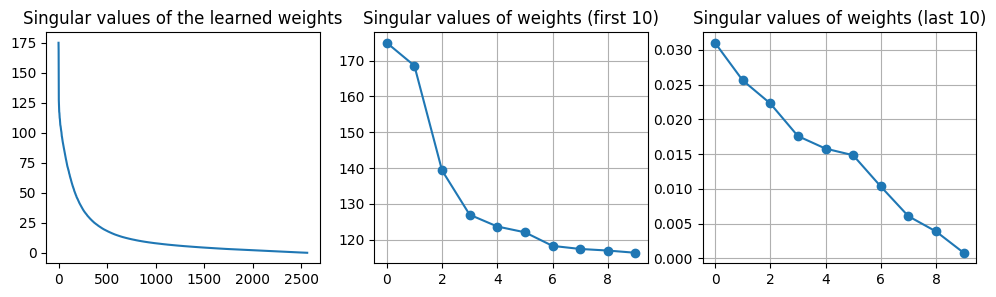

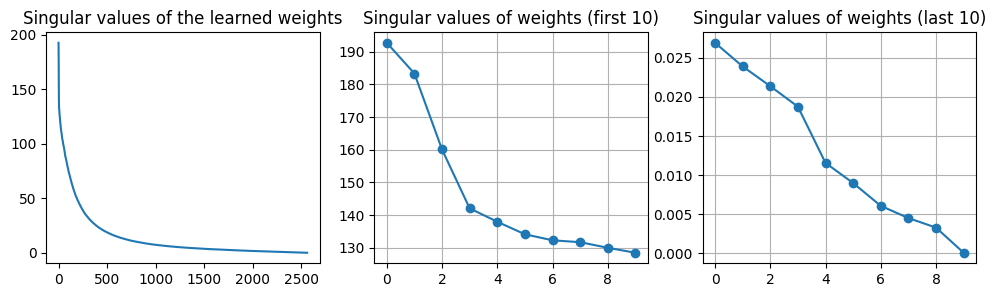

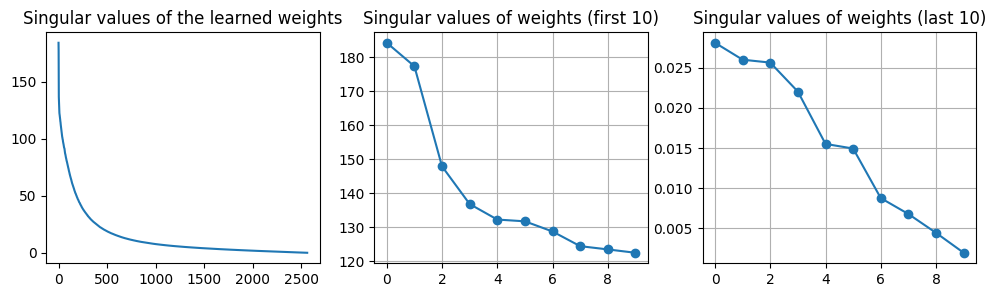

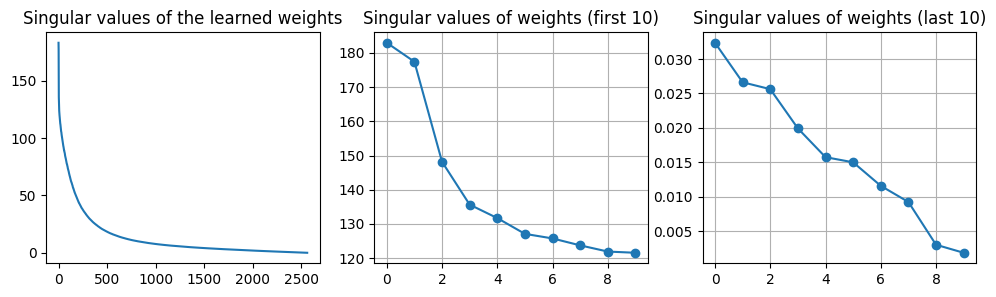

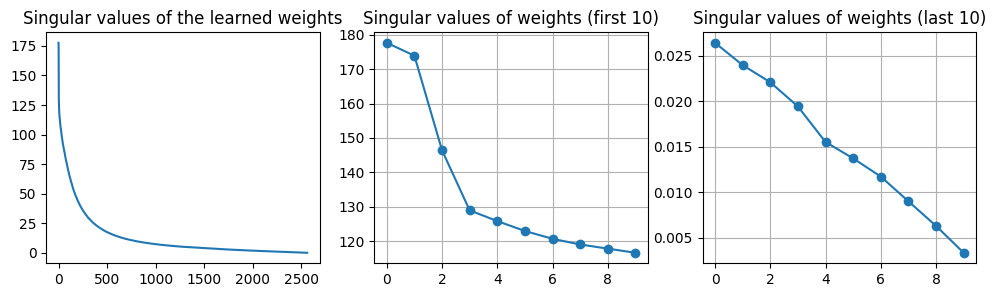

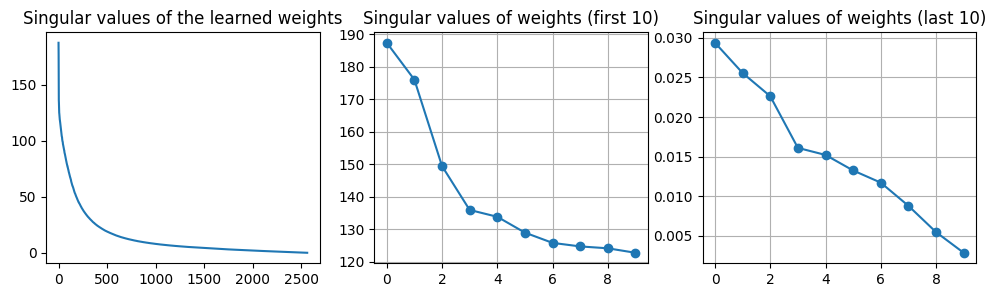

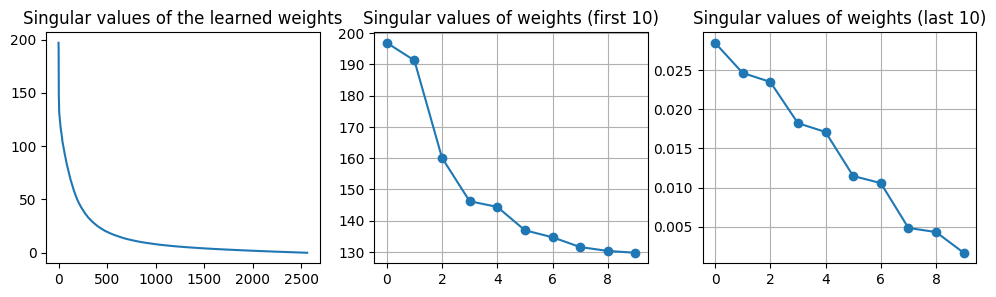

In [9]:
N = 10
first_components = []
last_components = []

#svd for the learned weights
for linear_model in linear_models:
    with torch.no_grad():
        U, S, Vh = torch.linalg.svd(
            linear_model.weight.float(),
            full_matrices=True)
    first_components.append(Vh[:N,:].cpu().numpy())
    last_components.append(Vh[-N:,:].cpu().numpy())
    # plot of the singular values and a zoom on the first N
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    ax[0].plot(S.detach().cpu().numpy())
    ax[0].set_title("Singular values of the learned weights")
    ax[1].plot(S.detach().cpu().numpy()[:N], 'o-')
    ax[1].set_title(f"Singular values of weights (first {N})")
    ax[1].grid()
    ax[2].plot(S.detach().cpu().numpy()[-N:], 'o-')
    ax[2].set_title(f"Singular values of weights (last {N})")
    ax[2].grid()
    plt.show()

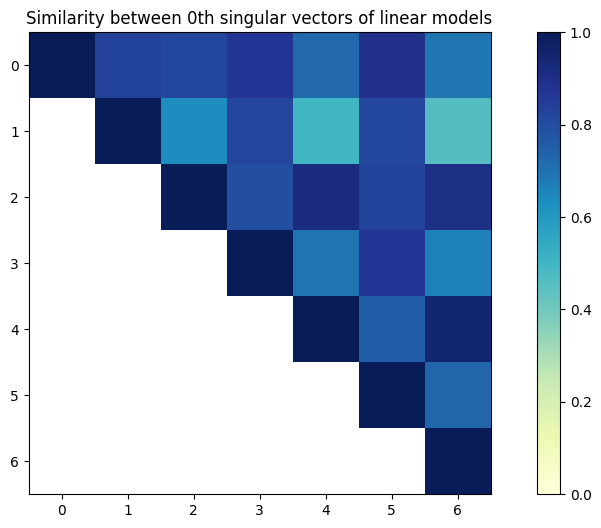

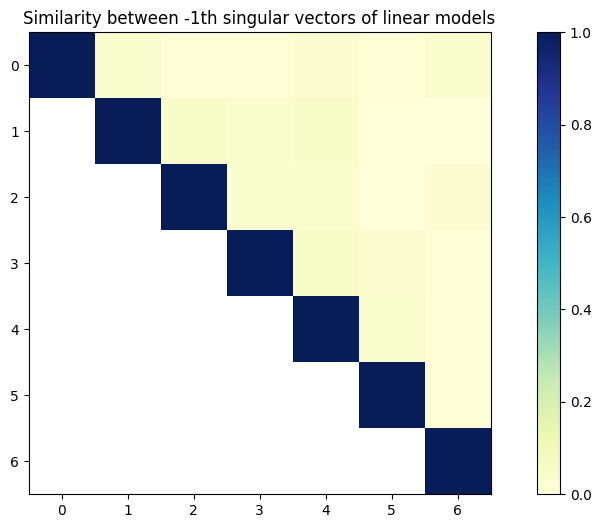

In [10]:

def plot_sims(components, i_comp):
    plt.figure(figsize=(12, 6))
    similarities = np.zeros((len(components), len(components)))

    for i, c1s in enumerate(components):
        for j, c2s in enumerate(components):
            c1 = c1s[i_comp,:]
            c2 = c2s[i_comp,:]
            # print(c1.shape, c2.shape)
            #compute similarity
            if i <= j:
                similarities[i,j] = np.abs(np.dot(c1,c2)) / (np.linalg.norm(c1) * np.linalg.norm(c2))
            else:
                similarities[i,j] = np.nan

    plt.title(f"Similarity between {i_comp}th singular vectors of linear models")
    plt.imshow(similarities, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.clim(0,1)
    plt.show()

plot_sims(first_components, 0)
plot_sims(last_components, -1)

using the first 10 components
baseline, angles between random 10-dimensional spaces
mean angle between two random subspaces: 79.90°
grassmann between two random subspaces: 4.57

angles between first component spaces of 7linear models
mean mean: 32.01°


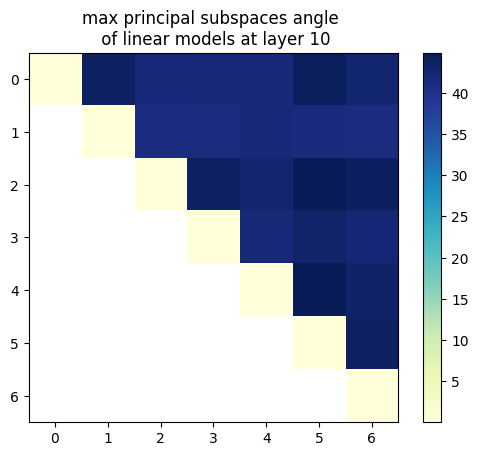

angles between last component spaces of 7 linear models
mean mean: 64.10°


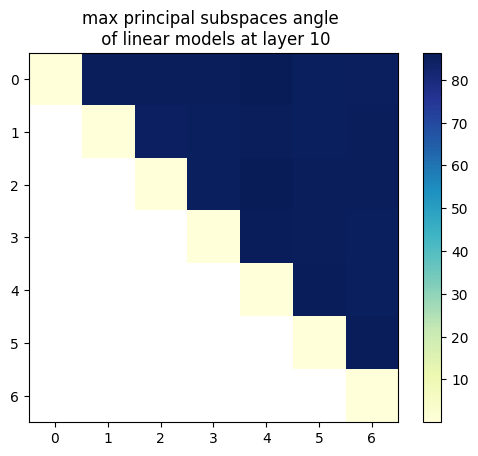

angles between first and last component spaces of 7 linear models
mean mean: 89.55°


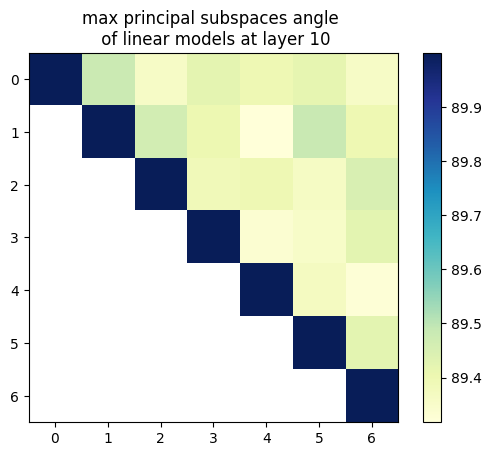

In [19]:
from scipy.linalg import subspace_angles

def plot_angles(components1, components2, dist="grassmann"):
    """
    components: list of numpy arrays of shape (n_components, n_features)
    dist: distance metric to use, either 'grassmann' or 'max' 
        'grassmann' computes the grassmann distance between the subspaces spanned by the components
        'max' computes the maximum principal angle between the subspaces spanned by the components, **in degrees**
    """
    angles = np.zeros((len(components1), len(components2)))

    for i, c1s in enumerate(components1):
        for j, c2s in enumerate(components2):
            
            #compute similarity
            if i <= j:
                all_angles = subspace_angles(c1s.T, c2s.T) #suppose c1s and c2s are (n_features, n_components) : vectors are columns
                if dist == "grassmann":
                    angles[i,j] = np.sqrt(np.sum(all_angles**2))
                elif dist == "mean":
                    angles[i,j] = np.rad2deg(np.mean(all_angles))
                elif dist == "max":
                    angles[i,j] = np.rad2deg(np.max(all_angles))
                else: 
                    raise ValueError(f"Unknown distance metric: {dist}")
            else:
                angles[i,j] = np.nan

    #print mean angle is scientific notation
    print(f"mean {dist}: {np.nanmean(angles):.2f}{'' if dist == 'grassmann' else '°'}")
    plt.title(f"max principal subspaces angle \n of linear models at layer {layer}")
    plt.imshow(angles, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    if dist == 'max': 
        plt.clim(0, 90)
    plt.show()

#baseline, compute angle between first and last components
print(f"using the first {N} components")
print(f"baseline, angles between random {N}-dimensional spaces")
shape = first_components[0].shape
comp1 = np.random.rand(shape[1],shape[0])
comp2 = np.random.rand(shape[1],shape[0])
angles = subspace_angles(comp1, comp2)
print(f"mean angle between two random subspaces: {np.rad2deg(np.mean(angles)):.2f}°")
print(f"grassmann between two random subspaces: {np.sqrt(np.sum(angles**2)):.2f}\n")

print(f"angles between first component spaces of {len(linear_models)}linear models")
dist = "max"
dist = "mean"

plot_angles(first_components, first_components, dist=dist)

print(f"angles between last component spaces of {len(linear_models)} linear models")
plot_angles(last_components, last_components, dist=dist)


print(f"angles between first and last component spaces of {len(linear_models)} linear models")
plot_angles(first_components, last_components, dist=dist)

In [20]:
## project first components on vocab
#get tok 10 mappings :
def project_on_vocab(model, rep, k=10):
    """ project a representation on the vocabulary of the model
    Args:
        model: the model to use
        rep: the representation to project
        k: number of top tokens to return
    """
    #get top 10 tokens
    logits = torch.tensor(rep).float().cuda() @ model.W_U
    topk_inds = torch.topk(logits, k).indices
    topk_tokens = model.tokenizer.convert_ids_to_tokens(topk_inds.cpu().numpy())
    return topk_tokens

print("first components projections on vocab")
print(50*"-")
for comps in first_components:
    comp = comps[0]
    print(project_on_vocab(model, comp, k=10))

print("\nlast components projections on vocab")
print(50*"-")
for comps in last_components:
    comp = comps[0]
    print(project_on_vocab(model, comp, k=10))

first components projections on vocab
--------------------------------------------------
['withstanding', 'arag', 'Ġantid', 'Blog', '->', 'ĠCourt', 'Ġspit', 'Ġbashing', 'arter', 'City']
['withstanding', 'tenance', 'arag', 'ĠPromise', 'ĠCity', 'west', 'icularly', 'opping', '?)', 'arak']
['Leary', 'cule', 'uctor', 'ILLE', 'lder', 'ECA', 'jug', 'Donnell', 'jad', 'SER']
['withstanding', 'ĠCourt', 'City', 'tenance', 'west', 'foundland', 'ĠCity', 'Blog', 'Ġantid', '?)']
['Ġsl', 'Blog', 'bid', 'Ġlaunches', 'ĠHealth', 'Health', 'ĠCourt', 'Ġbid', '\'."', 'Ġantid']
['ttes', 'illery', 'uctor', 'IDS', 'animate', 'pole', 'ttp', 'mitt', 'Leary', 'ECK']
['ĠCourt', 'Ġlaunches', 'Health', 'Ġsl', 'bid', 'ĠGroup', 'rec', 'Ġbid', 'Blog', 'ise']

last components projections on vocab
--------------------------------------------------
['ĠSignature', 'ĠYounger', 'Merit', 'Premium', 'Border', 'uma', 'rick', 'ussia', 'akh', 'WIN']
['ĠGor', 'Ġstr', 'ĠStr', 'gob', 'str', 'emark', 'jun', 'ĠHW', 'ĠVend', 'ĠBane']
[

### Similariy of biases

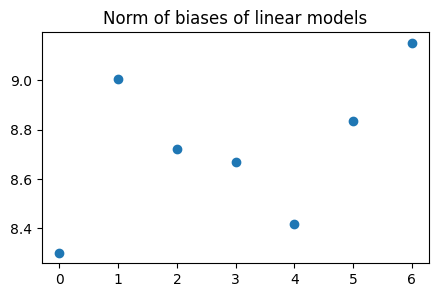

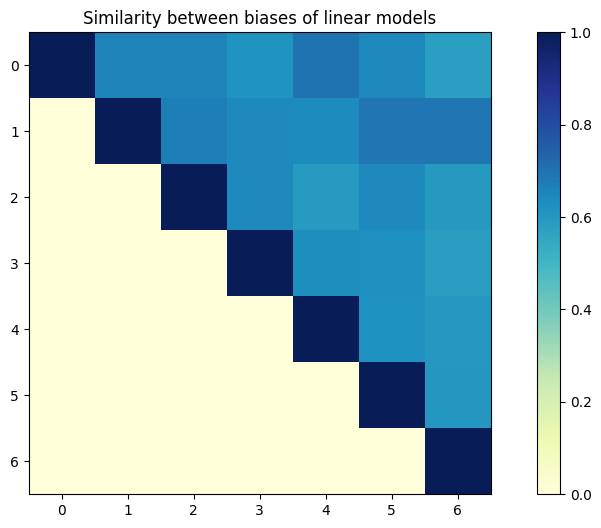

In [179]:
#compute the similarity between linear models biases 
biases = [m.bias.detach().cpu().numpy() for m in linear_models]

#plot the biases norm 
plt.figure(figsize=(5, 3))
norms = [np.linalg.norm(b) for b in biases]
plt.scatter(range(len(norms)), norms)
plt.title("Norm of biases of linear models")
plt.show()

plt.figure(figsize=(12, 6))
similarities = np.zeros((len(biases), len(biases)))

for i, b1 in enumerate(biases):
    for j, b2 in enumerate(biases):
        if i <= j:
            similarities[i,j] = np.abs(np.dot(b1,b2)) / (np.linalg.norm(b1) * np.linalg.norm(b2))

plt.title(f"Similarity between biases of linear models")
plt.imshow(similarities, cmap=plt.cm.YlGnBu)
plt.colorbar()
plt.show()

## Analysing linear models from different layers

In [35]:
layers = [9, 10, 11, 12, 13]
with_context = False
dataset_name = "CoNLL2003"
method = "in_context"
method = "average"

linear_models = {} #one model per layer


#load linear layers training results
for layer in layers:
    filtered_results = results_linear[
        (results_linear["layer"] == layer) & 
        (results_linear["dataset_name"] == dataset_name) & 
        (results_linear["with_context"] == with_context) &
        (results_linear["extraction_method"] == method)
        ]    
    for i, row in filtered_results.iterrows():
        path = row["path"]
        #open folder
        files = os.listdir(path)
        ckpts = [f for f in files if f.endswith(".pth")]
        if ckpts:
            #load last checkpoint
            ckpt = torch.load(path / ckpts[-1])
            linear_models[layer] = ckpt
            print(f"loaded {ckpts[-1]} from {path}")
            break
        else:
            print(f"Job {row['hash']} has {len(ckpts)} checkpoints")


loaded LinearFilter_phi-2_l9_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/567dab84b768ffec3da4d5749b73db1879975167c2da3918cb148cc05f42fcec
loaded LinearFilter_phi-2_l10_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/a30ddd36de1596cf418e78ceddcded0e31daa2e57ef873416efbd6a4a92dfa5e
loaded LinearFilter_phi-2_l11_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/4a074031e848e4b1ba5ff5c2b25085780b1e4f0039093a49c5a4d5d3ad1fab00
loaded LinearFilter_phi-2_l12_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/62a174652a9d8a1f0887c087fe83417b6d1fbe420424f2b28061de244686785a
loaded LinearFilter_phi-2_l13_e10.0noContext.pth from /home/morand/experiments_JeanZay/jobs/labelextractor.learnlinearfilter/23c2b0caceb8ccf38afc0be87096ff399296ddaad1a905575301a8d96168e0fb


### Computing SVD of the learned weights

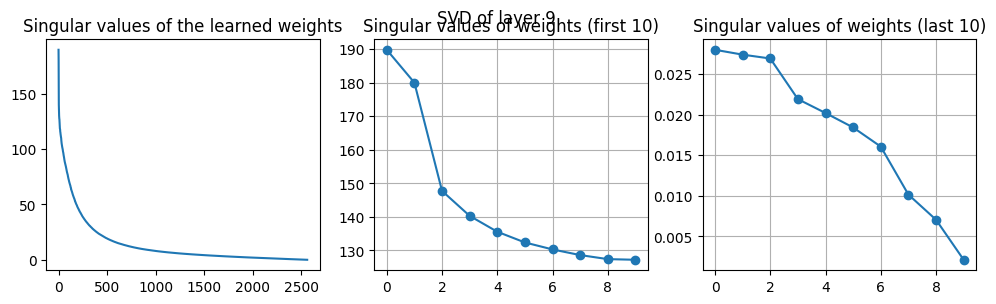

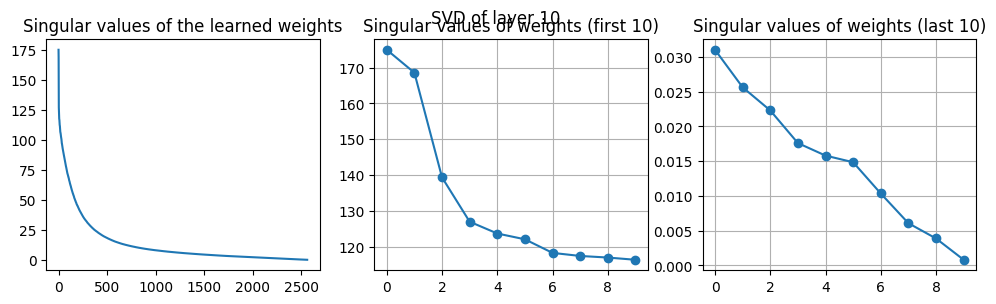

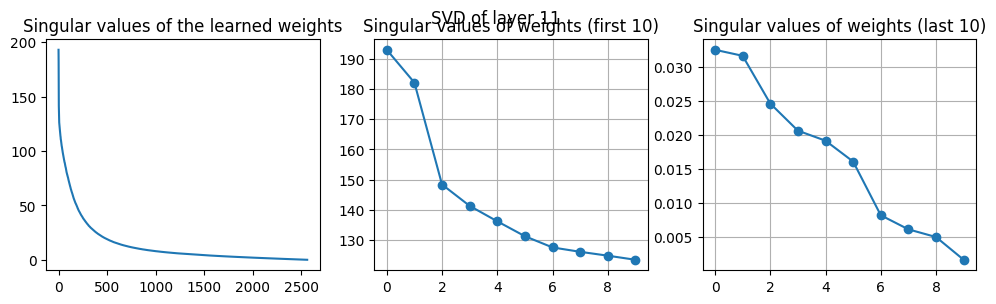

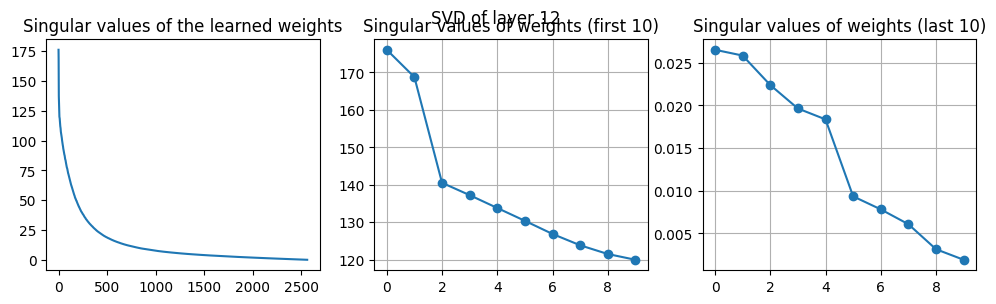

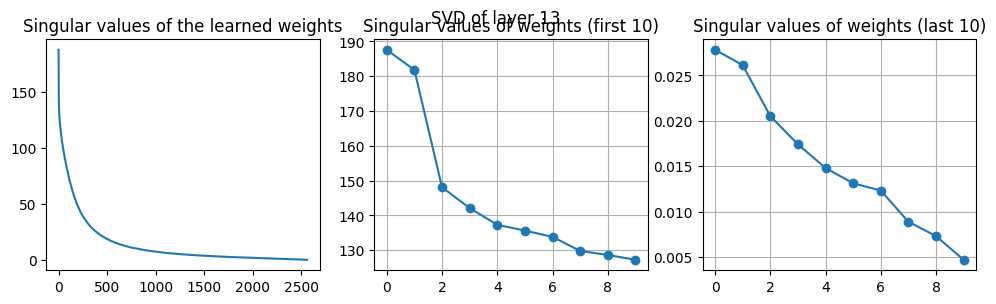

In [36]:
N = 10
first_components = {}
last_components = {}

#svd for the learned weights
for layer, linear_model in linear_models.items():
    with torch.no_grad():
        U, S, Vh = torch.linalg.svd(
            linear_model.weight.float(),
            full_matrices=True)
    first_components[layer] = Vh[:N,:].cpu().numpy()
    last_components[layer] = Vh[-N:,:].cpu().numpy()

    # plot of the singular values and a zoom on the first N
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    plt.suptitle(f"SVD of layer {layer}")
    ax[0].plot(S.detach().cpu().numpy())
    ax[0].set_title("Singular values of the learned weights")
    ax[1].plot(S.detach().cpu().numpy()[:N], 'o-')
    ax[1].set_title(f"Singular values of weights (first {N})")
    ax[1].grid()
    ax[2].plot(S.detach().cpu().numpy()[-N:], 'o-')
    ax[2].set_title(f"Singular values of weights (last {N})")
    ax[2].grid()
    #overall title
    plt.show()

### Comparing first and last components of different layers

In [32]:
#get list from dict values
first_comps = list(first_components.values())

indexes of layers: [10, 11, 12]


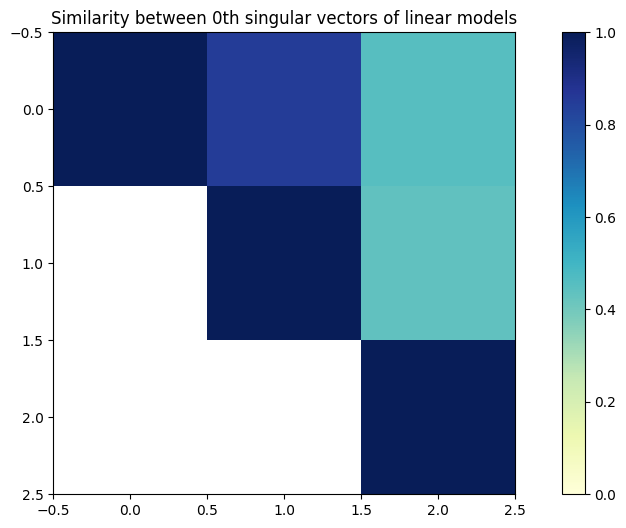

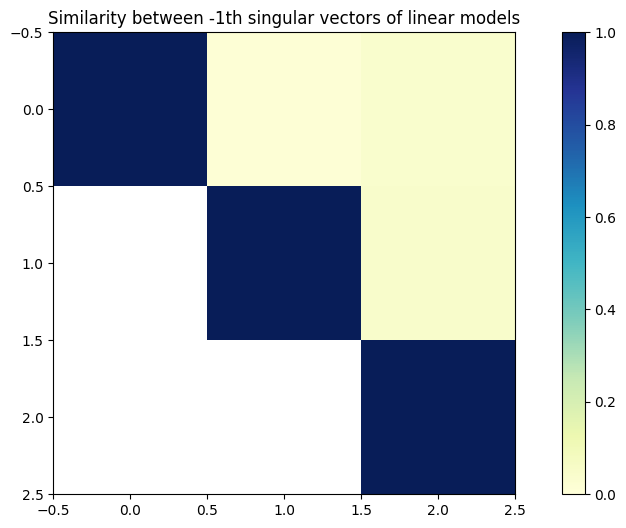

In [34]:
print(f"indexes of layers are {list(first_components.keys())}")
plot_sims(list(first_components.values()), 0)
plot_sims(list(last_components.values()), -1)

### Angles between subspaces

using the first 10 components
indexes of layers are [9, 10, 11, 12, 13]

baseline, angles between random 10-dimensional spaces
mean angle between two random subspaces: 79.82°
grassmann between two random subspaces: 4.57

angles between first component spaces of 5 linear models
mean grassmann: 1.84


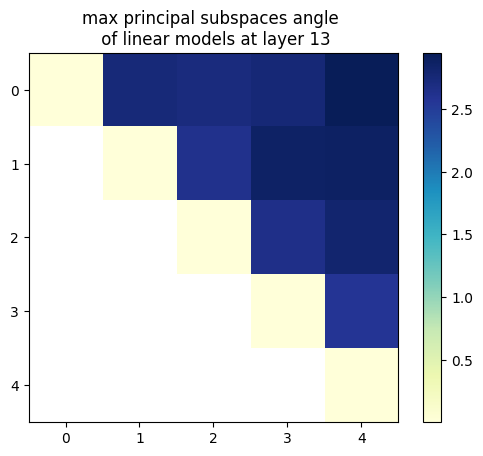

angles between last component spaces of 5 linear models
mean grassmann: 3.16


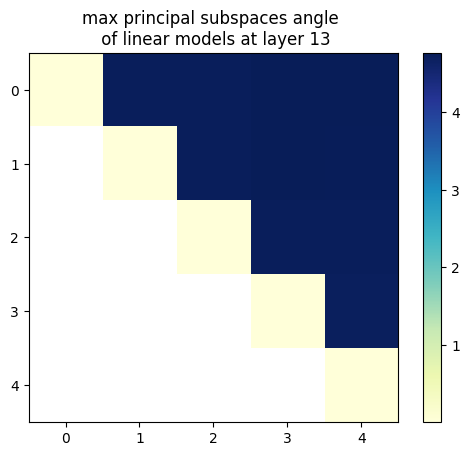

angles between first and last component spaces of 5 linear models
mean grassmann: 4.93


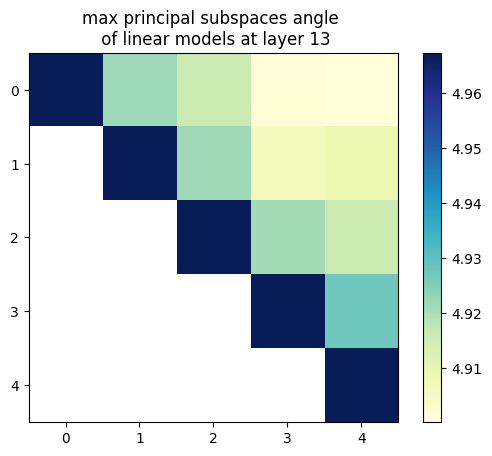

In [40]:

#baseline, compute angle between first and last components
print(f"using the first {N} components")
print(f"indexes of layers are {list(first_components.keys())}\n")

print(f"baseline, angles between random {N}-dimensional spaces")
# shape = first_components[0].shape
comp1 = np.random.rand(shape[1],shape[0])
comp2 = np.random.rand(shape[1],shape[0])
angles = subspace_angles(comp1, comp2)
print(f"mean angle between two random subspaces: {np.rad2deg(np.mean(angles)):.2f}°")
print(f"grassmann between two random subspaces: {np.sqrt(np.sum(angles**2)):.2f}\n")

print(f"angles between first component spaces of {len(linear_models)} linear models")
dist = "max"
dist = "mean"
dist = "grassmann"

plot_angles(first_components.values(), first_components.values(), dist=dist)

print(f"angles between last component spaces of {len(linear_models)} linear models")
plot_angles(last_components.values(), last_components.values(), dist=dist)


print(f"angles between first and last component spaces of {len(linear_models)} linear models")
plot_angles(first_components.values(), last_components.values(), dist=dist)

# Misc
## Correlation between reconstructions and representations counts in the Pile

In [180]:
res = []
counts = {}

In [181]:
counts_file = f"/home/morand/code/entityrepresentations/counts_{dataset_name}_TestEntities.json"
print(f"loading {counts_file}...")
with open(counts_file) as json_file:
    counts = json.load(json_file)

entity = "Mc Donald's"
entity = "CALGARY"
print(f"Entity {entity} appears {counts[entity]} times in the Pile")

loading /home/morand/code/entityrepresentations/counts_CoNLL2003_TestEntities.json...
Entity CALGARY appears 8336 times in the Pile


In [182]:
import requests, time

payload = {
    'corpus': 'v4_piletrain_llama',
    'query_type': 'count',
    'query': 'University of Washington',
}

for item in tqdm(test_dataset):
    entity = item["entity"]
    if entity not in counts:
        payload['query'] = entity
        result = requests.post('https://api.infini-gram.io/', json=payload).json()
        time.sleep(0.001)
        counts[entity] = result['count']

print(counts)



NameError: name 'test_dataset' is not defined

In [51]:
print(len(counts))
#save counts
import json
with open('counts_CoNLL2003_TestEntities.json', 'w') as f:
    json.dump(counts, f)

2531
